In [522]:
import os
import numpy as np
import pandas as pd
import math
import pandapower as pp
import pandapower.plotting as ppplot
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point
from pandapower import plotting
from pandapower.plotting import simple_plot

# plotting convenience
%matplotlib inline
plt.rcParams.update({"figure.figsize": (10,6)})


# Define the data directory, as data folder in the parent OXENERGYMScPython directory
DATA_DIR = os.path.join("..", "Data")


 #2 Load core dataframes used in the notebook

In [523]:
# Update filenames to match your local files
gens_df = pd.read_csv(os.path.join(DATA_DIR, "UK_2025_gen_above100MW_EPSG4326 (1).csv"))  # example name
print(gens_df.head())
# If your notebook already loaded equivalent objects, comment these lines out and reuse them

   id  Name Fueltype      Technology  Capacity (MW)      lat     lon
0  37  Sloy    Hydro    Run-Of-River          153.0  56.2615 -4.7636
1  38  Foye    Hydro    Run-Of-River          320.0  57.2558 -4.4941
2  39  Ffes    Hydro    Run-Of-River          384.0  52.9808 -3.9686
3  40  Dino    Hydro    Run-Of-River         1728.0  53.1206 -4.1153
4  41  Crua    Hydro  Pumped Storage          440.0  56.4192 -5.0127


In [524]:
demand_region = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="MAIN DATA", skiprows=14, index_col=0)  # Demand by region
demand_region.head()


c:\Users\catz0911\AppData\Local\miniforge3\envs\GeoPower\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


,Name,Minor FLOP,Major FLOP,P(Gross),Q Gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Dx Storage Demand,Micro storage Demand
Elexon ID,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,Demand (MW),Demand (MVAR),Demand (MVAR),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Total Capacity (MW),Demand (MW),Demand (MW)
ABHA1,Abham,F6,F,329.998528,0.884376,-20.860707,60.717,212.007,0.988,1.917,97.242,0,0
ABNE_P,Abernethy,T4,T,38.702785,-0.688556,-2.012223,0.239,26.904,18.833,0.129,0,0,0
ABTH_1,Aberthaw,H2,H,174.13994,8.653586,-32.728783,0.54,108.668,0.545,0,29.537,0,0
ACTL_2,Acton Lane 66kV,A7,A,24.658002,-2.236142,-2.761841,0.142,5.303,0,0.279,0.363,0,0


In [442]:
# import grid supply point locations
gsp_locations = gpd.read_file("C:\\Users\\catz0911\\Downloads\\gsp_regions_20250109\\Proj_4326\\GSP_regions_4326_20250109.geojson")  # GSP lat lon mapping
gsp_locations.head()

,GSPs,GSPGroup,geometry
0,NETS,_N,"MULTIPOLYGON (((-4.46073 55.17672, -4.26086 55..."
1,CHAP,_N,"MULTIPOLYGON (((-3.07582 54.97528, -3.07616 54..."
2,BISW_1,_E,"MULTIPOLYGON (((-3.29887 52.4249, -3.29965 52...."
3,PORD,_N,"MULTIPOLYGON (((-4.25977 55.86125, -4.26002 55..."
4,BROR_P,_P,"MULTIPOLYGON (((-3.53593 58.15656, -3.53709 58..."


In [443]:
# import grid supply point locations
gsp_points = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="GSP info", skiprows=4, index_col=0)  # GSP lat lon mapping
gsp_points["geometry"] = gpd.points_from_xy(gsp_points.Longitude, gsp_points.Latitude)
gsp_points = gpd.GeoDataFrame(gsp_points, geometry="geometry", crs="EPSG:4326")
gsp_points[["Longitude", "Latitude"]] = gsp_points[["Longitude", "Latitude"]].astype(float)

# major flop is the first letter of major flop
gsp_points["Major FLOP"] = gsp_points["Minor FLOP"].astype(str).str[0]

# convert to british national grid
gsp_points = gsp_points.to_crs(epsg=27700)

In [444]:
gsp_points.head()

,GSP ID,GSP Group,Minor FLOP,Name,Latitude,Longitude,Comments,geometry,Major FLOP
NaN,ABHA1,_L,F6,Abham,50.471559,-3.729489,NaN,POINT (277366.77 64956.935),F
NaN,ABNE_P,_P,T4,Abernethy,56.339456,-3.293751,NaN,POINT (320119.11 717096.631),T
NaN,ABTH_1,_K,H2,Aberthaw,51.385210,-3.403318,NaN,POINT (302444.047 166064.259),H
NaN,ACTL_2,_H,A7,Acton Lane 66kV,51.534951,-0.257050,NaN,POINT (520984.73 183222.12),A
NaN,ACTL_C,_C,A7,Acton Lane 22kV,51.534951,-0.257050,NaN,POINT (520984.73 183222.12),A


In [445]:
# import GSP polygons as well in British National Grid coordinates 
gsp_polygons = gpd.read_file("C:\\Users\\catz0911\\Downloads\\gsp_regions_20250109\\Proj_4326\\GSP_regions_4326_20250109.geojson")
gsp_polygons.crs = "EPSG:4326"
gsp_polygons = gsp_polygons.to_crs(epsg=27700)


In [446]:
# Separate pipe-delimited GSPs into separate rows
gsp_polygons["GSPs"] = gsp_polygons["GSPs"].str.split("|")
gsp_polygons = gsp_polygons.explode("GSPs").reset_index(drop=True)

# Fill in missing Minor FLOP and Major FLOP data from gsp_points
# Drop the existing FLOP columns from the merge (they may have NaN values)
gsp_polygons = gsp_polygons.drop(columns=["GSP ID", "Major FLOP", "Minor FLOP"], errors="ignore")

# Merge again with gsp_points to get complete FLOP data
gsp_polygons = gsp_polygons.merge(
    gsp_points[["GSP ID", "Major FLOP", "Minor FLOP", "GSP Group"]], 
    left_on="GSPs", 
    right_on="GSP ID", 
    how="left"
)

In [447]:
gsp_polygons.head()

,GSPs,GSPGroup,geometry,GSP ID,Major FLOP,Minor FLOP,GSP Group
0,NETS,_N,"MULTIPOLYGON (((243392.631 589698.709, 255939....",NETS,S,S6,_N
1,CHAP,_N,"MULTIPOLYGON (((331236.338 565048.182, 331214....",CHAP,S,S6,_N
2,BISW_1,_E,"MULTIPOLYGON (((311775.048 281560.56, 311722.7...",BISW_1,L,L2,_E
3,PORD,_N,"MULTIPOLYGON (((258665.362 665428.688, 258649....",PORD,S,S5,_N
4,BROR_P,_P,"MULTIPOLYGON (((309710.615 919660.325, 309641....",BROR_P,T,T5,_P


## Group by Major FLOP

In [448]:
major_FLOP_polygons = gsp_polygons.dissolve(by="Major FLOP").reset_index()

In [449]:
# groupby major flop
demand_region_major_flop = demand_region.groupby("Major FLOP").agg({"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})

In [450]:
# add major flop polygons
demand_region_major_flop = gpd.GeoDataFrame(demand_region_major_flop.merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")
demand_region_major_flop.head()

,Major FLOP,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,GSP Group,geometry
0,A,9134.278885,1195.647333,530.148,1.017,3.452,717.33,_A,"MULTIPOLYGON (((499272 142548, 499230 142600, ..."
1,B,3497.82783,299.440241,1198.495,73.426,0.469,180.963,_H,"MULTIPOLYGON (((449470.92 102396.843, 449438.2..."
2,C,2144.666292,192.110474,923.545,239.613,0.474,676.853,_A,"MULTIPOLYGON (((532060.114 143491.058, 531951...."
3,D,2176.819603,92.612757,971.335,29.002,1.17,428.49,_H,"MULTIPOLYGON (((493191.034 206824.291, 493032...."
4,E,1258.536836,30.104401,1087.715,3.592,0.467,132.384,_L,"MULTIPOLYGON (((347800.463 88920.721, 346449.7..."


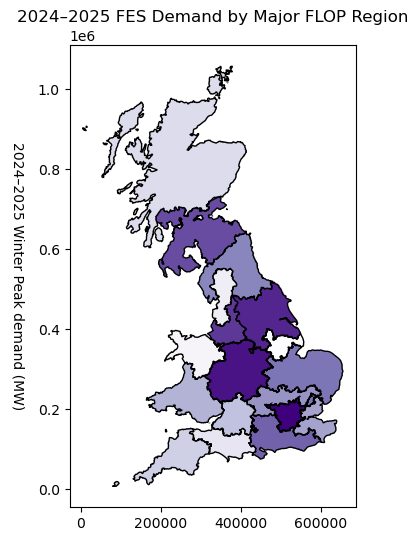

In [451]:
ax = demand_region_major_flop.plot(
    column="P(Gross)",
    cmap="Purples",
    legend=False,
    edgecolor="black"
)

# Get colorbar from the figure by searching for mappable
fig = ax.get_figure()
cbar = fig.axes[-1]   # last axis is the colorbar if it exists
cbar.set_ylabel("2024–2025 Winter Peak demand (MW)", rotation=270, labelpad=20)
ax.set_title("2024–2025 FES Demand by Major FLOP Region")
plt.show()

## Group by GSP Group

In [452]:
demand_region_major_flop.head()

,Major FLOP,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,GSP Group,geometry
0,A,9134.278885,1195.647333,530.148,1.017,3.452,717.33,_A,"MULTIPOLYGON (((499272 142548, 499230 142600, ..."
1,B,3497.82783,299.440241,1198.495,73.426,0.469,180.963,_H,"MULTIPOLYGON (((449470.92 102396.843, 449438.2..."
2,C,2144.666292,192.110474,923.545,239.613,0.474,676.853,_A,"MULTIPOLYGON (((532060.114 143491.058, 531951...."
3,D,2176.819603,92.612757,971.335,29.002,1.17,428.49,_H,"MULTIPOLYGON (((493191.034 206824.291, 493032...."
4,E,1258.536836,30.104401,1087.715,3.592,0.467,132.384,_L,"MULTIPOLYGON (((347800.463 88920.721, 346449.7..."


In [453]:
# dno regions can be downloaded as a separate file or following the process above and dissolving on GSP Group

# groupby GSP Group
demand_region_group_flop = demand_region_major_flop.dissolve(by="GSP Group", aggfunc={"P(Gross)": "sum",
                                                                       "Q Gross": "sum",
                                                                       "Embedded Solar": "sum",
                                                                       "Embedded Wind": "sum",
                                                                       "Embedded Hydro": "sum",
                                                                       "Embedded Other": "sum"})
demand_region_group_flop.head()



,geometry,P(Gross),Q Gross,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other
GSP Group,,,,,,,
_A,"MULTIPOLYGON (((532060.114 143491.058, 531951....",14565.848854,1547.083941,4032.821,844.196,4.063,2277.187
_B,"MULTIPOLYGON (((464072.308 344197.587, 464077....",582.766968,52.364216,790.545,219.316,0,128.889
_D,"POLYGON ((359053.349 360773.162, 358238.069 36...",6734.27045,316.881312,1097.827,985.303,23.333,2117.822
_E,"MULTIPOLYGON (((391462.26 228439.664, 390968.4...",6783.562498,614.213435,2257.646,185.661,2.302,1173.16
_F,"POLYGON ((462114.269 500809.013, 461231.28 500...",2987.452807,36.873463,691.417,783.877,13.679,859.103


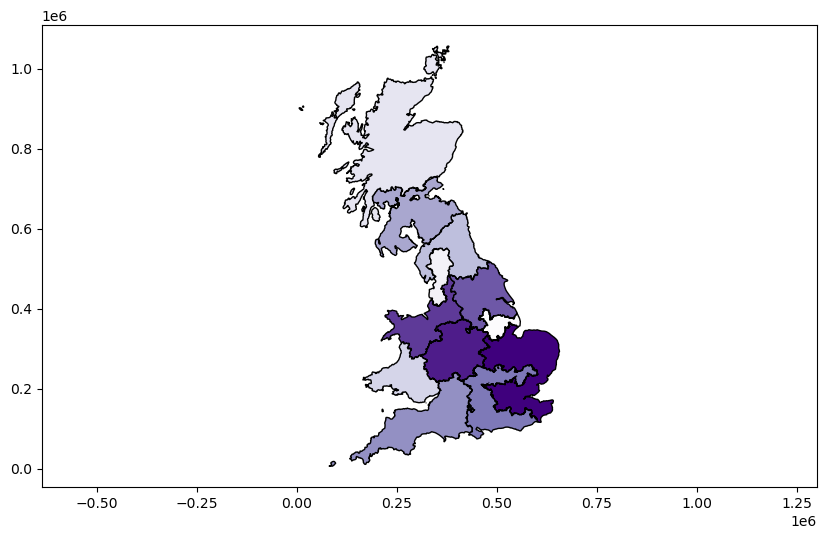

In [454]:
ax = demand_region_group_flop.plot(column="P(Gross)", cmap="Purples", legend=False, edgecolor="black")
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

### Embedded solar and wind generation

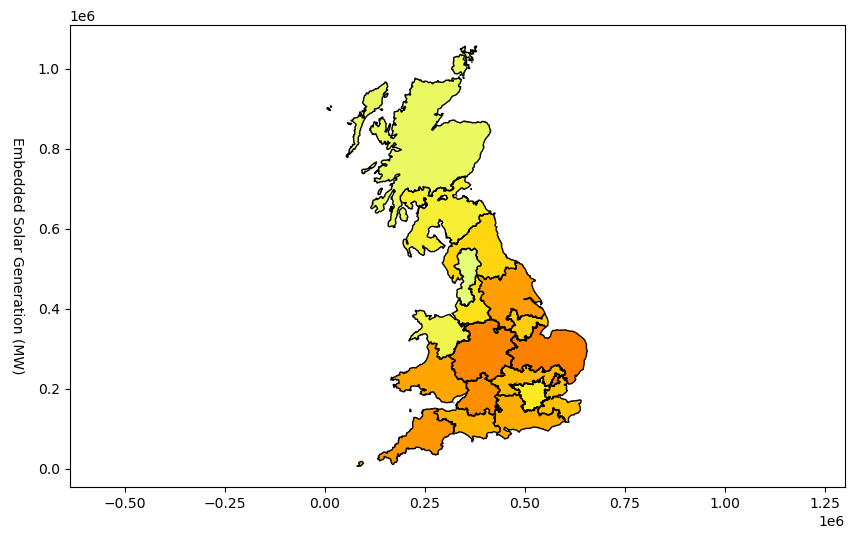

In [455]:
ax = demand_region_major_flop.plot(column="Embedded Solar", cmap="Wistia", legend=False, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[-1]
cbar.set_ylabel("Embedded Solar Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

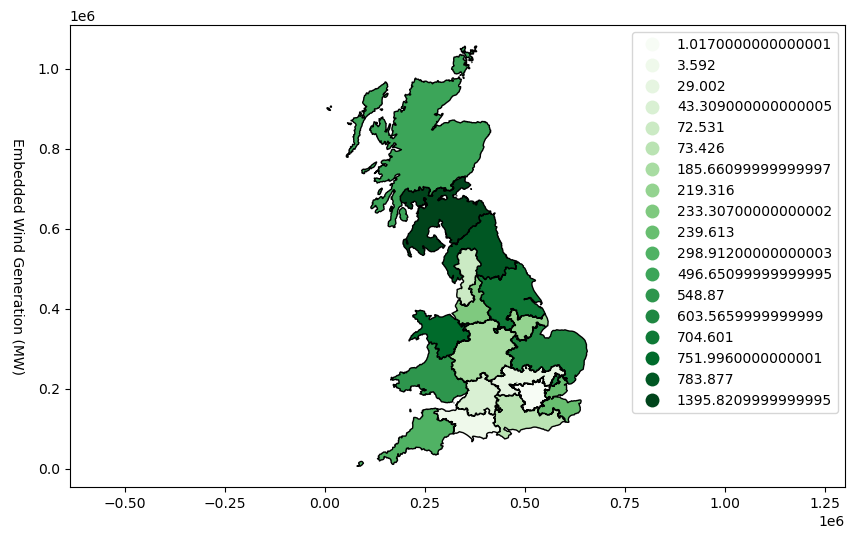

In [456]:
ax = demand_region_major_flop.plot(column="Embedded Wind", cmap="Greens", legend=True, edgecolor="black")
# color bar label
cbar = ax.get_figure().get_axes()[-1]
cbar.set_ylabel("Embedded Wind Generation (MW)", rotation=270, labelpad=20)
# ensure x and y have same aspect ratio
ax.set_aspect('equal', adjustable='datalim')

## Import generation data (Again)

In [457]:
gens_df = pd.read_csv(os.path.join(DATA_DIR, "UK_2025_gen_above100MW_EPSG4326 (1).csv"), index_col=0)
print(gens_df.shape)
# convert to geopandas using longitude and latitude columns
gen_gdf = gpd.GeoDataFrame(gens_df, geometry=gpd.points_from_xy(gens_df.lon, gens_df.lat), crs="EPSG:4326")

# remove gilbraltar 
gen_gdf = gen_gdf[gen_gdf.lat >= 40]

# convert to british national grid
gen_gdf = gen_gdf.to_crs(epsg=27700)

(118, 6)


In [458]:
# assign large_gen_gdf to nearest polygon of major_FLOP_polygons
gen_gdf = gpd.sjoin_nearest(
    gen_gdf, 
    major_FLOP_polygons[["Major FLOP", "geometry"]], 
    how="left"
)
    
# drop the index column created by sjoin
gen_gdf = gen_gdf.drop(columns=["index_right"], errors="ignore")

In [459]:
gen_gdf.shape



(118, 8)

In [460]:
gen_gdf.head()

,Name,Fueltype,Technology,Capacity (MW),lat,lon,geometry,Major FLOP
id,,,,,,,,
37,Sloy,Hydro,Run-Of-River,153.0,56.2615,-4.7636,POINT (228923.845 711102.499),T
38,Foye,Hydro,Run-Of-River,320.0,57.2558,-4.4941,POINT (249643.853 821104.04),T
39,Ffes,Hydro,Run-Of-River,384.0,52.9808,-3.9686,POINT (267928.79 344418.088),M
40,Dino,Hydro,Run-Of-River,1728.0,53.1206,-4.1153,POINT (258539.759 360247.612),M
41,Crua,Hydro,Pumped Storage,440.0,56.4192,-5.0127,POINT (214268.534 729293.732),T


In [461]:
# group by type and major flop

gen_grouped = gen_gdf.groupby(["Major FLOP", "Fueltype"]).agg({'Capacity (MW)': 'sum'})
gen_grouped
#Putting this on the map


Capacity (MW)
Major FLOP Fueltype                    
A          Natural Gas           1267.0
B          Natural Gas           1465.0
           Wind                   400.0
C          Natural Gas           3990.0
           Solar                  378.3
           Wind                  1070.0
D          Natural Gas           1490.0
E          Natural Gas           1258.0
           Nuclear               5284.0
F          Natural Gas           1045.0
G          Natural Gas           1258.0
H          Natural Gas           4241.0
           Wind                   228.0
J          Natural Gas           4043.0
           Nuclear               1320.0
           Wind                  6959.8
K          Natural Gas           3633.0
           Wind                  1061.0
L          Natural Gas            236.0
M          Hydro                 2112.0
           Natural Gas           2015.0
           Wind                   576.0
N          Natural Gas           1855.0
           Wind                   254.0
P          Natural Gas           5462.0
           Solid Biomass         2718.0
           Wind                  1300.0
Q          Natural Gas            509.8
           Solid Biomass          299.0
           Wind                  5165.2
R          Nuclear               2676.0
S          Natural Gas           1008.0
           Nuclear               1370.0
           Wind                  3776.4
T          Hydro                  913.0
           Natural Gas           1653.0
           Wind                  4003.4

In [462]:
gen_grouped.xs('Wind', level='Fueltype')

,Capacity (MW)
Major FLOP,
B,400.0
C,1070.0
H,228.0
J,6959.8
K,1061.0
M,576.0
N,254.0
P,1300.0
Q,5165.2


In [463]:
large_wind_major_flop_polygons = gpd.GeoDataFrame(gen_grouped.xs('Wind', level='Fueltype').merge(major_FLOP_polygons[["Major FLOP", "GSP Group", "geometry"]],
                                                                      left_on="Major FLOP",
                                                                        right_on="Major FLOP",
                                                                          how="left"),
                                                                      geometry="geometry",
                                            crs="EPSG:27700")


<Axes: >

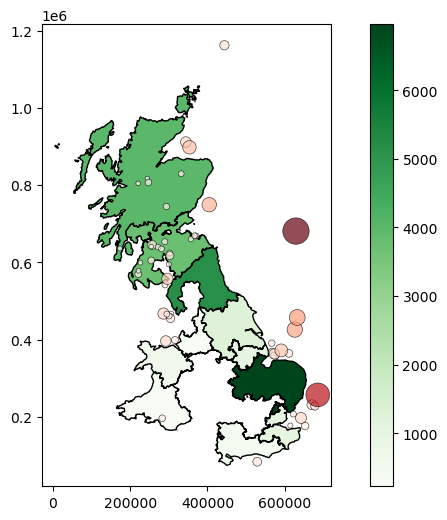

In [464]:
ax = large_wind_major_flop_polygons.plot(column="Capacity (MW)", cmap="Greens", legend=True, edgecolor="black")

# add points from gen_gdf with point size related to capacity
wind_gen = gen_gdf[gen_gdf["Fueltype"]=='Wind']
wind_gen.plot(
    ax=ax, 
    column="Capacity (MW)", 
    markersize=wind_gen["Capacity (MW)"] / 10,  # Scale factor to adjust size
    cmap="Reds",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5
)

In [465]:
def haversine_km(lon1, lat1, lon2, lat2):
    """Great-circle distance in km (inputs in degrees)."""
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, (lon1, lat1, lon2, lat2))
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return 2 * R * math.asin(math.sqrt(a))

# read buses and create them with geodata
buses_df = pd.read_csv(os.path.join(DATA_DIR, "buses.csv"))

~Building the Network~

In [466]:
# Create a new empty pandapower network
net = pp.create_empty_network()
net["bus_geodata"] = pd.DataFrame(columns=["longitude", "latitude"])


~Buses~

In [467]:
for _, row in buses_df.iterrows():
    b = pp.create_bus(net, vn_kv=row["v_nom"], name=row["name"])
    net.bus_geodata.loc[b] = [row["longitude"], row["latitude"]]

~Checking Lines~

In [468]:

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, (lon1, lat1, lon2, lat2))
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * R * math.asin(math.sqrt(a))

lines_df = pd.read_csv(os.path.join(DATA_DIR, "lines.csv"))

created = 0
skipped = 0

for i, row in lines_df.iterrows():
    # debug print per 10 rows
    if i % 10 == 0:
        print(f"processing row {i}")

    # robust name -> index resolution (strip and case-insensitive)
    def resolve_bus(val):
        if pd.isna(val):
            raise KeyError("empty bus value")
        # numeric index?
        if isinstance(val, (int, float)) and float(val).is_integer():
            return int(val)
        s = str(val).strip()
        if s.isdigit():
            return int(s)
        # exact name match first
        matches = net.bus[net.bus["name"] == s]
        if len(matches):
            return int(matches.index[0])
        # case-insensitive match
        matches = net.bus[net.bus["name"].str.lower() == s.lower()]
        if len(matches):
            return int(matches.index[0])
        # try contains (trimmed whitespace)
        matches = net.bus[net.bus["name"].str.strip().str.lower().str.contains(s.lower())]
        if len(matches):
            return int(matches.index[0])
        raise KeyError(f"could not resolve bus name/index: {val!r}")

    try:
        fb = resolve_bus(row["bus0"])
        tb = resolve_bus(row["bus1"])
    except Exception as e:
        print(f"Skipping line row {i}: {e}")
        skipped += 1
        continue

    # get coordinates and compute length
    lon1, lat1 = net.bus_geodata.loc[fb, ["longitude", "latitude"]]
    lon2, lat2 = net.bus_geodata.loc[tb, ["longitude", "latitude"]]
    length_km = haversine_km(float(lon1), float(lat1), float(lon2), float(lat2))

    # create the line
    pp.create_line_from_parameters(
        net,
        from_bus=int(fb),
        to_bus=int(tb),
        length_km=float(length_km),
        r_ohm_per_km=float(row["r"] * 0.15)/length_km,
        x_ohm_per_km=float(row["x"] * 0.15)/length_km,
        c_nf_per_km=float(row["c"])/length_km,
        max_i_ka=float(row["max i"]),
        parallel=2
        
    )
    created += 1

print(f"created {created} lines, skipped {skipped} rows")
print("net.line rows:", net.line.shape[0])
# show last 10 lines to confirm variety
print(net.line.tail(10))


processing row 0
processing row 10
processing row 20
processing row 30
processing row 40
processing row 50
processing row 60
processing row 70
processing row 80
created 84 lines, skipped 0 rows
net.line rows: 84
    name std_type  from_bus  to_bus  length_km  r_ohm_per_km  x_ohm_per_km  \
74  None     None        21       7  47.012138      0.002553      0.081681   
75  None     None        21       7  47.012138      0.025525      0.091891   
76  None     None        22       7  42.841654      0.001849      0.029131   
77  None     None        22       7  42.841654      0.000896      0.009635   
78  None     None        22      21  48.639950      0.000938      0.010954   
79  None     None        22      21  48.639950      0.000888      0.010954   
80  None     None        23       4  32.312937      0.002971      0.000743   
81  None     None        23       4  32.312937      0.002971      0.000743   
82  None     None        23      19  87.738308      0.008206      0.547081   
83  None

In [469]:
print(net.bus_geodata.head())
print(net.line.head())


   longitude   latitude
0   1.159651  52.088738
1  -0.978219  51.291877
2  -2.181395  53.361456
3  -3.072208  53.223030
4  -2.229827  55.677255
   name std_type  from_bus  to_bus  length_km  r_ohm_per_km  x_ohm_per_km  \
0  None     None         0       8  83.711200      0.001003      0.006594   
1  None     None         0       8  83.711200      0.001003      0.006594   
2  None     None         0      24  94.556827      0.004518      0.054063   
3  None     None         0      24  94.556827      0.003350      0.036296   
4  None     None         1      10  42.251060      0.003863      0.039762   

   c_nf_per_km  g_us_per_km  max_i_ka   df  parallel  type  in_service   geo  
0     5.344856          0.0      4.01  1.0         2  None        True  None  
1     5.344856          0.0      4.01  1.0         2  None        True  None  
2    14.058653          0.0      2.29  1.0         2  None        True  None  
3     7.692074          0.0      2.29  1.0         2  None        True  None 

Simple Plot

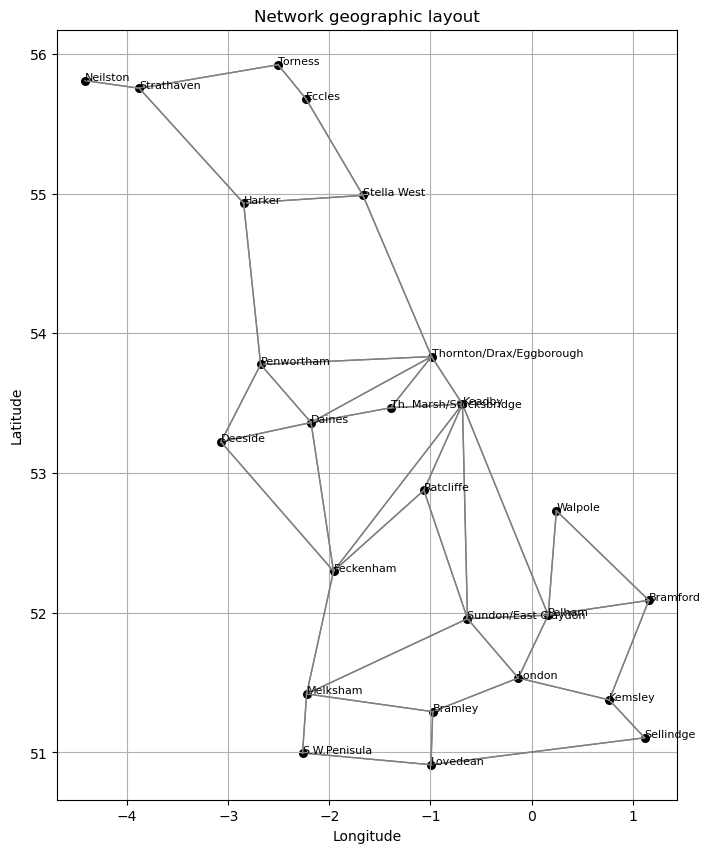

In [470]:
import matplotlib.pyplot as plt

# extract coords
coords = net.bus_geodata
xs = coords["longitude"] if "longitude" in coords.columns else coords["x"]
ys = coords["latitude"] if "latitude" in coords.columns else coords["y"]

plt.figure(figsize=(8, 10))

# plot buses
plt.scatter(xs, ys, s=30, color="black")

# label buses
for idx, row in coords.iterrows():
    plt.text(row["longitude"], row["latitude"], net.bus.loc[idx, "name"], fontsize=8)

# plot lines connecting buses
for _, line in net.line.iterrows():
    fb = line["from_bus"]
    tb = line["to_bus"]
    x1, y1 = coords.loc[fb, ["longitude", "latitude"]]
    x2, y2 = coords.loc[tb, ["longitude", "latitude"]]
    plt.plot([x1, x2], [y1, y2], color="gray", linewidth=1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Network geographic layout")
plt.grid(True)
plt.show()


~Colourful Plot~

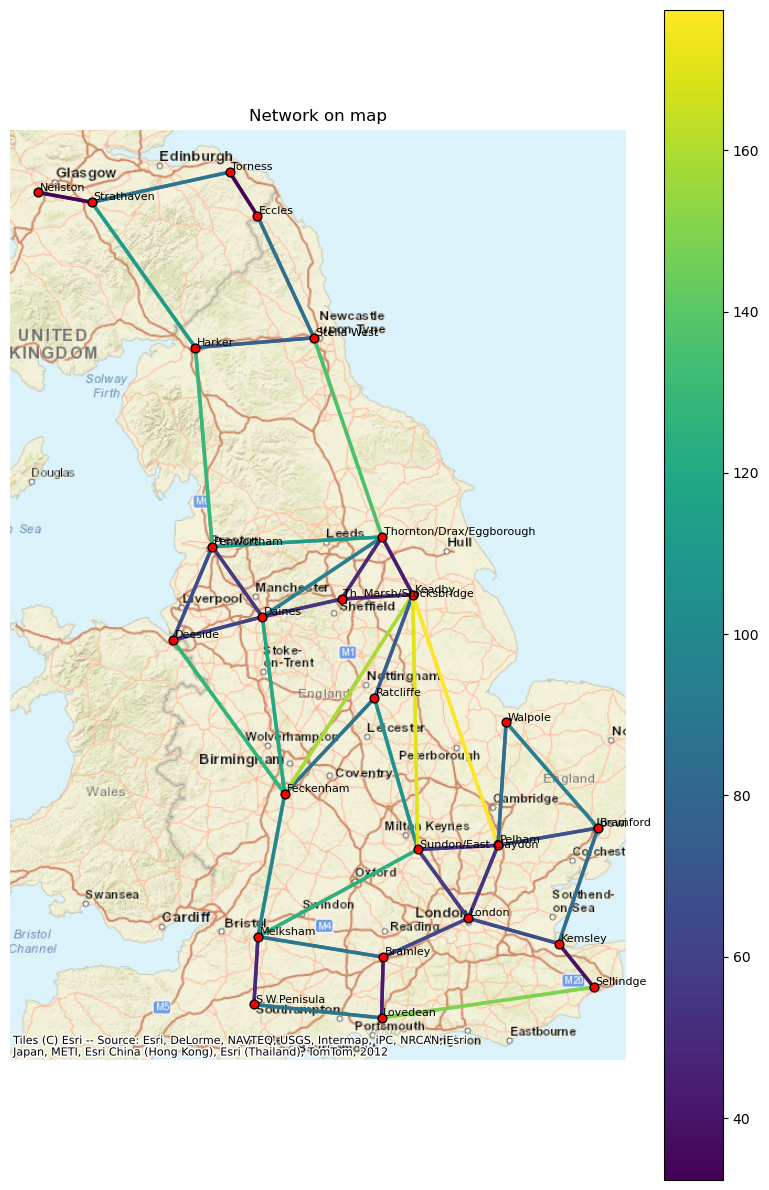

In [471]:
import contextily as ctx
from shapely.geometry import Point, LineString

# build GeoDataFrame of bus points (assumes net.bus_geodata has longitude/latitude)
bus_idx = net.bus_geodata.index
lon = net.bus_geodata.loc[bus_idx, "longitude"].astype(float)
lat = net.bus_geodata.loc[bus_idx, "latitude"].astype(float)

gdf_buses = gpd.GeoDataFrame(
    net.bus.loc[bus_idx, ["name", "vn_kv"]].copy(),
    geometry=gpd.points_from_xy(lon, lat),
    crs="EPSG:4326"
)

# build GeoDataFrame of lines as LineString using bus coords
lines_geoms = []
line_props = []
for _, line in net.line.iterrows():
    fb = int(line["from_bus"])
    tb = int(line["to_bus"])
    lon1, lat1 = float(net.bus_geodata.loc[fb, "longitude"]), float(net.bus_geodata.loc[fb, "latitude"])
    lon2, lat2 = float(net.bus_geodata.loc[tb, "longitude"]), float(net.bus_geodata.loc[tb, "latitude"])
    lines_geoms.append(LineString([(lon1, lat1), (lon2, lat2)]))
    line_props.append({
        "length_km": float(line.get("length_km", 0)),
        "r_ohm_per_km": float(line.get("r_ohm_per_km", 0))
    })

gdf_lines = gpd.GeoDataFrame(line_props, geometry=lines_geoms, crs="EPSG:4326")

# convert both to Web Mercator for basemap
gdf_buses = gdf_buses.to_crs(epsg=3857)
gdf_lines = gdf_lines.to_crs(epsg=3857)

# plotting
fig, ax = plt.subplots(figsize=(8, 12))
# draw lines with a colormap based on length (you can change cmap)
gdf_lines.plot(ax=ax, column="length_km", linewidth=2.5, cmap="viridis", legend=True, alpha=0.9)

# draw bus points and labels
gdf_buses.plot(ax=ax, color="red", markersize=40, edgecolor="black", zorder=3)

# add labels (use projected coords)
for idx, row in gdf_buses.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.text(x + 2000, y + 2000, row["name"], fontsize=8, zorder=4)  # offset a bit so labels don't sit on points

# add basemap (choose provider you like)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldStreetMap)  # or ctx.providers.OpenStreetMap.Mapnik

ax.set_axis_off()
ax.set_title("Network on map")
plt.tight_layout()



In [472]:
demand_dataframe = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="MAIN DATA", skiprows=14, index_col=0)  # Demand by region
gsp_info_dataframe = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_V2 - Copy.xlsm"), sheet_name="GSP info", skiprows=4, index_col=0)  # Coordinates of GSP region

c:\Users\catz0911\AppData\Local\miniforge3\envs\GeoPower\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


In [473]:
buses_df.head()

,name,v_nom,carrier,longitude,latitude
0,Bramford,400,AC,1.159651,52.088738
1,Bramley,400,AC,-0.978219,51.291877
2,Daines,400,AC,-2.181395,53.361456
3,Deeside,400,AC,-3.072208,53.223030
4,Eccles,400,AC,-2.229827,55.677255


In [474]:
merged_load_and_demand = gsp_info_dataframe.merge(
    demand_dataframe,
    left_on="GSP ID",
    right_on="Elexon ID",
    how="inner"
)

merged_load_and_demand.head()

,GSP ID,GSP Group,Minor FLOP_x,Name_x,Latitude,Longitude,Comments,Name_y,Minor FLOP_y,Major FLOP,P(Gross),Q Gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Dx Storage Demand,Micro storage Demand
0,ABHA1,_L,F6,Abham,50.471559,-3.729489,NaN,Abham,F6,F,329.998528,0.884376,-20.860707,60.717,212.007,0.988,1.917,97.242,0,0
1,ABNE_P,_P,T4,Abernethy,56.339456,-3.293751,NaN,Abernethy,T4,T,38.702785,-0.688556,-2.012223,0.239,26.904,18.833,0.129,0,0,0
2,ABTH_1,_K,H2,Aberthaw,51.385210,-3.403318,NaN,Aberthaw,H2,H,174.13994,8.653586,-32.728783,0.54,108.668,0.545,0,29.537,0,0
3,ACTL_2,_H,A7,Acton Lane 66kV,51.534951,-0.257050,NaN,Acton Lane 66kV,A7,A,24.658002,-2.236142,-2.761841,0.142,5.303,0,0.279,0.363,0,0
4,ACTL_C,_C,A7,Acton Lane 22kV,51.534951,-0.257050,NaN,Acton Lane 22kV,A7,A,33.985529,0.442958,-3.806579,0,0,0,0,0,0,0


In [475]:
# Find closest bus to each GSP and add to merged_load_and_demand (uses `buses_df` with columns: name, v_nom, carrier, longitude, latitude)
import geopandas as gpd

# Build GeoDataFrame for buses (buses_df long/lat in degrees)
gdf_buses = gpd.GeoDataFrame(buses_df.copy(), geometry=gpd.points_from_xy(buses_df.longitude, buses_df.latitude), crs="EPSG:4326")

# Prepare GSP GeoDataFrame: prefer `gsp_points` if present, otherwise use `gsp_info_dataframe`
if 'gsp_points' in globals():
    gsp_gdf = gsp_points.copy()
    # ensure GSP ID is a column
    if 'GSP ID' not in gsp_gdf.columns:
        gsp_gdf = gsp_gdf.reset_index()
else:
    gsp_gdf = gsp_info_dataframe.copy()
    if 'GSP ID' not in gsp_gdf.columns:
        gsp_gdf = gsp_gdf.reset_index()
    if 'geometry' not in gsp_gdf.columns:
        gsp_gdf['geometry'] = gpd.points_from_xy(gsp_gdf.Longitude, gsp_gdf.Latitude)
    gsp_gdf = gpd.GeoDataFrame(gsp_gdf, geometry='geometry', crs='EPSG:4326')

# Ensure both geopandas dataframes are in a metric CRS for distance (British National Grid EPSG:27700)
# If gsp_gdf is already in 27700 this will be a no-op
try:
    gdf_buses_proj = gdf_buses.to_crs(epsg=27700)
except Exception:
    gdf_buses_proj = gdf_buses.copy()
    gdf_buses_proj.crs = 'EPSG:4326'
    gdf_buses_proj = gdf_buses_proj.to_crs(epsg=27700)

try:
    gsp_proj = gsp_gdf.to_crs(epsg=27700)
except Exception:
    gsp_proj = gsp_gdf.copy()
    if gsp_proj.crs is None:
        gsp_proj.crs = 'EPSG:4326'
    gsp_proj = gsp_proj.to_crs(epsg=27700)

# Keep only relevant columns from buses for the spatial join
buses_for_join = gdf_buses_proj[['name','geometry']].copy()
buses_for_join = buses_for_join.rename(columns={'name':'Closest_Bus'})

# Spatial join (nearest): this adds the nearest bus and distance in metres
nearest = gpd.sjoin_nearest(gsp_proj, buses_for_join, how='left', distance_col='Closest_Bus_dist_m')
# Ensure GSP ID is a column for merging (reset_index if it was the index)
if 'GSP ID' not in nearest.columns:
    nearest = nearest.reset_index()
# Keep only required columns and rename bus column
nearest = nearest[['GSP ID','Closest_Bus','Closest_Bus_dist_m']]

# Merge nearest bus info into merged_load_and_demand (preserve existing rows)
merged_load_and_demand = merged_load_and_demand.merge(nearest, on='GSP ID', how='left')

# Report
print('Added Closest_Bus and Closest_Bus_dist_m to merged_load_and_demand')
display(merged_load_and_demand[['GSP ID','Closest_Bus','Closest_Bus_dist_m']].head())

Added Closest_Bus and Closest_Bus_dist_m to merged_load_and_demand


,GSP ID,Closest_Bus,Closest_Bus_dist_m
0,ABHA1,S.W.Penisula,118675.279822
1,ABNE_P,Torness,67408.708530
2,ABTH_1,Melksham,82060.461900
3,ACTL_2,London,8682.153098
4,ACTL_C,London,8682.153098


In [476]:
merged_load_and_demand.head()
#To print column 'P(Gross)', which contains the gross power demand for each GSP



,GSP ID,GSP Group,Minor FLOP_x,Name_x,Latitude,Longitude,Comments,Name_y,Minor FLOP_y,Major FLOP,...,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Dx Storage Demand,Micro storage Demand,Closest_Bus,Closest_Bus_dist_m
0,ABHA1,_L,F6,Abham,50.471559,-3.729489,NaN,Abham,F6,F,...,-20.860707,60.717,212.007,0.988,1.917,97.242,0,0,S.W.Penisula,118675.279822
1,ABNE_P,_P,T4,Abernethy,56.339456,-3.293751,NaN,Abernethy,T4,T,...,-2.012223,0.239,26.904,18.833,0.129,0,0,0,Torness,67408.708530
2,ABTH_1,_K,H2,Aberthaw,51.385210,-3.403318,NaN,Aberthaw,H2,H,...,-32.728783,0.54,108.668,0.545,0,29.537,0,0,Melksham,82060.461900
3,ACTL_2,_H,A7,Acton Lane 66kV,51.534951,-0.257050,NaN,Acton Lane 66kV,A7,A,...,-2.761841,0.142,5.303,0,0.279,0.363,0,0,London,8682.153098
4,ACTL_C,_C,A7,Acton Lane 22kV,51.534951,-0.257050,NaN,Acton Lane 22kV,A7,A,...,-3.806579,0,0,0,0,0,0,0,London,8682.153098


In [477]:
gens_df = pd.read_csv(os.path.join(DATA_DIR, "UK_2025_gen_above100MW_EPSG4326 (1).csv"), index_col=0)
gens_df.head()

,Name,Fueltype,Technology,Capacity (MW),lat,lon
id,,,,,,
37,Sloy,Hydro,Run-Of-River,153.0,56.2615,-4.7636
38,Foye,Hydro,Run-Of-River,320.0,57.2558,-4.4941
39,Ffes,Hydro,Run-Of-River,384.0,52.9808,-3.9686
40,Dino,Hydro,Run-Of-River,1728.0,53.1206,-4.1153
41,Crua,Hydro,Pumped Storage,440.0,56.4192,-5.0127


In [478]:
# Aggregate demand and embedded resources by bus (requires 'Closest_Bus' column in merged_load_and_demand)
import pandas as pd

def _choose_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    lower_cols = {col.lower(): col for col in df.columns}
    for c in candidates:
        lc = c.lower()
        if lc in lower_cols:
            return lower_cols[lc]
    return None

# candidate name variants
p_candidates = ['P(Gross)', 'P Gross', 'P_gross', 'P']
q_candidates = ['Q Net', 'Q_net', 'Q Gross', 'Q']
emb_storage_candidates = ['Embedded Storage', 'Embedded storage', 'Embedded_Storage', 'Storage']
emb_solar_candidates = ['Embedded Solar', 'Embedded solar', 'Embedded_Solar', 'Solar']
emb_wind_candidates = ['Embedded Wind', 'Embedded wind', 'Embedded_Wind', 'Wind']
emb_hydro_candidates = ['Embedded Hydro', 'Embedded hydro', 'Embedded_Hydro', 'Hydro']
emb_other_candidates = ['Embedded Other', 'Embedded other', 'Embedded_Other', 'Other']

# locate actual columns in merged_load_and_demand
p_col = _choose_col(merged_load_and_demand, p_candidates)
q_col = _choose_col(merged_load_and_demand, q_candidates)
emb_storage_col = _choose_col(merged_load_and_demand, emb_storage_candidates)
emb_solar_col = _choose_col(merged_load_and_demand, emb_solar_candidates)
emb_wind_col = _choose_col(merged_load_and_demand, emb_wind_candidates)
emb_hydro_col = _choose_col(merged_load_and_demand, emb_hydro_candidates)
emb_other_col = _choose_col(merged_load_and_demand, emb_other_candidates)

if 'Closest_Bus' not in merged_load_and_demand.columns:
    raise KeyError("Closest_Bus column not found. Run nearest-bus assignment cell first.")

# coerce numeric where present
for col in [p_col, q_col, emb_storage_col, emb_solar_col, emb_wind_col, emb_hydro_col, emb_other_col]:
    if col is not None:
        merged_load_and_demand[col] = pd.to_numeric(merged_load_and_demand[col], errors='coerce').fillna(0)

# build aggregation mapping
agg_map = {}
if p_col: agg_map[p_col] = 'sum'
if q_col: agg_map[q_col] = 'sum'
if emb_storage_col: agg_map[emb_storage_col] = 'sum'
if emb_solar_col: agg_map[emb_solar_col] = 'sum'
if emb_wind_col: agg_map[emb_wind_col] = 'sum'
if emb_hydro_col: agg_map[emb_hydro_col] = 'sum'
if emb_other_col: agg_map[emb_other_col] = 'sum'

if not agg_map:
    raise KeyError('No matching columns found to aggregate in merged_load_and_demand')

bus_agg = merged_load_and_demand.groupby('Closest_Bus').agg(agg_map).reset_index()

# rename columns to requested output names
rename_map = {}
if p_col: rename_map[p_col] = 'P gross'
if q_col: rename_map[q_col] = 'Q net'
if emb_storage_col: rename_map[emb_storage_col] = 'Embedded Storage'
if emb_solar_col: rename_map[emb_solar_col] = 'Embedded Solar'
if emb_wind_col: rename_map[emb_wind_col] = 'Embedded Wind'
if emb_hydro_col: rename_map[emb_hydro_col] = 'Embedded Hydro'
if emb_other_col: rename_map[emb_other_col] = 'Embedded Other'
bus_agg = bus_agg.rename(columns=rename_map)

# order columns and rename bus column
ordered = ['Closest_Bus', 'P gross', 'Q net', 'Embedded Storage', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Embedded Other']
present = [c for c in ordered if c in bus_agg.columns]
bus_agg = bus_agg[present]
bus_agg = bus_agg.rename(columns={'Closest_Bus':'bus name'})

# ensure numeric and fill missing
for c in bus_agg.columns:
    if c != 'bus name':
        bus_agg[c] = pd.to_numeric(bus_agg[c], errors='coerce').fillna(0)

bus_aggregated_loads = bus_agg.copy()
print('Created bus_aggregated_loads with columns:')
print(list(bus_aggregated_loads.columns))
display(bus_aggregated_loads)

# Total P(Gross)

Created bus_aggregated_loads with columns:
['bus name', 'P gross', 'Q net', 'Embedded Storage', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Embedded Other']


,bus name,P gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other
0,Bramford,1098.236114,20.890673,275.327,870.965,146.529,0.024,385.917
1,Bramley,1243.603041,26.332899,4.671,298.236,0.590,0.422,46.534
2,Daines,3593.678118,299.588005,126.951,371.656,125.235,2.950,715.252
3,Deeside,3434.948607,-20.658503,85.019,901.527,832.427,20.147,1440.496
4,Eccles,108.028363,18.921384,1.802,29.931,183.538,0.509,3.728
5,Feckenham,4186.541979,488.850420,145.499,1335.648,138.086,0.763,726.201
6,Harker,568.657529,42.606022,58.763,156.800,263.771,46.336,139.204
7,Keadby,1050.364202,55.829779,45.090,492.207,206.092,0.000,632.450
8,Kemsley,1459.150701,114.514662,281.148,534.120,98.295,0.046,402.987
9,London,9025.517013,1115.462226,163.187,485.269,2.635,3.876,790.555


In [479]:
bus_agg


,bus name,P gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other
0,Bramford,1098.236114,20.890673,275.327,870.965,146.529,0.024,385.917
1,Bramley,1243.603041,26.332899,4.671,298.236,0.590,0.422,46.534
2,Daines,3593.678118,299.588005,126.951,371.656,125.235,2.950,715.252
3,Deeside,3434.948607,-20.658503,85.019,901.527,832.427,20.147,1440.496
4,Eccles,108.028363,18.921384,1.802,29.931,183.538,0.509,3.728
5,Feckenham,4186.541979,488.850420,145.499,1335.648,138.086,0.763,726.201
6,Harker,568.657529,42.606022,58.763,156.800,263.771,46.336,139.204
7,Keadby,1050.364202,55.829779,45.090,492.207,206.092,0.000,632.450
8,Kemsley,1459.150701,114.514662,281.148,534.120,98.295,0.046,402.987
9,London,9025.517013,1115.462226,163.187,485.269,2.635,3.876,790.555


In [480]:
# Find closest bus for each generator and add as column to gens_df
import geopandas as gpd

# Build GeoDataFrame for generators (gens_df has lat/lon in degrees)
gen_points = gpd.GeoDataFrame(gens_df.copy(), geometry=gpd.points_from_xy(gens_df.lon, gens_df.lat), crs='EPSG:4326')

# Build GeoDataFrame for buses (buses_df has longitude/latitude in degrees)
bus_points = gpd.GeoDataFrame(buses_df.copy(), geometry=gpd.points_from_xy(buses_df.longitude, buses_df.latitude), crs='EPSG:4326')

# Project both to metric CRS (EPSG:27700 British National Grid) for accurate distance
gen_proj = gen_points.to_crs(epsg=27700)
bus_proj = bus_points.to_crs(epsg=27700)

# Keep only bus name and geometry for the spatial join
bus_for_join = bus_proj[['name', 'geometry']].copy()
bus_for_join = bus_for_join.rename(columns={'name': 'Closest_Bus'})

# Spatial join (nearest): find closest bus for each generator
nearest = gpd.sjoin_nearest(gen_proj, bus_for_join, how='left', distance_col='dist_to_bus_m')

# Extract generator index and closest bus name
gens_df['Closest_Bus'] = nearest['Closest_Bus'].values
gens_df['Distance_to_Bus_m'] = nearest['dist_to_bus_m'].values

# Display result
print('Added Closest_Bus and Distance_to_Bus_m columns to gens_df')
display(gens_df[['Name', 'Fueltype', 'Capacity (MW)', 'Closest_Bus', 'Distance_to_Bus_m']].head(10))

Added Closest_Bus and Distance_to_Bus_m columns to gens_df


,Name,Fueltype,Capacity (MW),Closest_Bus,Distance_to_Bus_m
id,,,,,
37,Sloy,Hydro,153.0,Neilston,54888.977694
38,Foye,Hydro,320.0,Neilston,161182.599082
39,Ffes,Hydro,384.0,Deeside,65796.850708
40,Dino,Hydro,1728.0,Deeside,70660.267677
41,Crua,Hydro,440.0,Neilston,77472.371603
98,Didcot,Natural Gas,1490.0,Bramley,41665.955630
103,Heym,Nuclear,2676.0,Penwortham,32083.282229
105,Torn,Nuclear,1370.0,Torness,7985.287245
107,Sizb,Nuclear,1320.0,Bramford,34412.383185


In [481]:
# Aggregate generation capacity by bus
bus_generation_capacity = gens_df.groupby('Closest_Bus').agg({'Capacity (MW)': 'sum'}).reset_index()
bus_generation_capacity = bus_generation_capacity.rename(columns={'Closest_Bus': 'Bus name'})

# Reorder columns to match requested output
bus_generation_capacity = bus_generation_capacity[['Bus name', 'Capacity (MW)']]

print('Created bus_generation_capacity with total capacity (MW) by bus')
display(bus_generation_capacity.head(15))

Created bus_generation_capacity with total capacity (MW) by bus


,Bus name,Capacity (MW)
0,Bramford,6345.8
1,Bramley,1490.0
2,Daines,1045.0
3,Deeside,5767.0
4,Harker,1149.0
5,Keadby,8567.0
6,Kemsley,4508.3
7,London,552.0
8,Lovedean,1865.0
9,Melksham,5727.0


In [482]:
# Merge bus_aggregated_loads with bus_generation_capacity on bus name
bus_complete = bus_aggregated_loads.merge(
    bus_generation_capacity,
    left_on='bus name',
    right_on='Bus name',
    how='outer'
)

# Use 'bus name' column and drop duplicate
bus_complete = bus_complete.drop(columns=['Bus name'], errors='ignore')

# Ensure numeric columns and fill NaN with 0
for col in bus_complete.columns:
    if col != 'bus name':
        bus_complete[col] = pd.to_numeric(bus_complete[col], errors='coerce').fillna(0)

print('Merged bus_aggregated_loads with bus_generation_capacity')
display(bus_complete.head(25))

Merged bus_aggregated_loads with bus_generation_capacity


,bus name,P gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Capacity (MW)
0,Bramford,1098.236114,20.890673,275.327,870.965,146.529,0.024,385.917,6345.8
1,Bramley,1243.603041,26.332899,4.671,298.236,0.590,0.422,46.534,1490.0
2,Daines,3593.678118,299.588005,126.951,371.656,125.235,2.950,715.252,1045.0
3,Deeside,3434.948607,-20.658503,85.019,901.527,832.427,20.147,1440.496,5767.0
4,Eccles,108.028363,18.921384,1.802,29.931,183.538,0.509,3.728,0.0
5,Feckenham,4186.541979,488.850420,145.499,1335.648,138.086,0.763,726.201,0.0
6,Harker,568.657529,42.606022,58.763,156.800,263.771,46.336,139.204,1149.0
7,Keadby,1050.364202,55.829779,45.090,492.207,206.092,0.000,632.450,8567.0
8,Kemsley,1459.150701,114.514662,281.148,534.120,98.295,0.046,402.987,4508.3
9,London,9025.517013,1115.462226,163.187,485.269,2.635,3.876,790.555,552.0


In [483]:
# Create loads at buses using bus_complete dataframe
# p_mw = P gross, q_mvar = Q net

for _, row in bus_complete.iterrows():
    bus_name = row['bus name']
    p_gross = row['P gross']
    q_net = row['Q net']
    
    # Find the bus index from net.bus using the bus name
    bus_matches = net.bus[net.bus['name'] == bus_name]
    
    if len(bus_matches) > 0:
        bus_idx = bus_matches.index[0]
        pp.create_load(net, bus=bus_idx, p_mw=p_gross, q_mvar=q_net, name=f"Load_{bus_name}")
    else:
        print(f"Warning: Bus '{bus_name}' not found in network")

print(f"Created {len(net.load)} loads in the network")
display(net.load[['bus', 'p_mw', 'q_mvar', 'name']].head(10))

Created 25 loads in the network


,bus,p_mw,q_mvar,name
0,0,1098.236114,20.890673,Load_Bramford
1,1,1243.603041,26.332899,Load_Bramley
2,2,3593.678118,299.588005,Load_Daines
3,3,3434.948607,-20.658503,Load_Deeside
4,4,108.028363,18.921384,Load_Eccles
5,5,4186.541979,488.850420,Load_Feckenham
6,6,568.657529,42.606022,Load_Harker
7,7,1050.364202,55.829779,Load_Keadby
8,8,1459.150701,114.514662,Load_Kemsley
9,9,9025.517013,1115.462226,Load_London


In [484]:
# Create static generators at each bus with total generation capacity
# p_mw = Embedded Storage + Embedded Solar + Embedded Wind + Embedded Hydro + Embedded Other + Capacity (MW)

for _, row in bus_complete.iterrows():
    bus_name = row['bus name']
    
    # Calculate total generation capacity
    emb_storage = row.get('Embedded Storage', 0)
    emb_solar = row.get('Embedded Solar', 0)
    emb_wind = row.get('Embedded Wind', 0)
    emb_hydro = row.get('Embedded Hydro', 0)
    emb_other = row.get('Embedded Other', 0)
    capacity = row.get('Capacity (MW)', 0)
    
    total_p_mw = emb_storage + emb_solar + emb_wind + emb_hydro + emb_other + capacity
    
    # Find the bus index from net.bus using the bus name
    bus_matches = net.bus[net.bus['name'] == bus_name]
    
    if len(bus_matches) > 0 and total_p_mw > 0:
        bus_idx = bus_matches.index[0]
        pp.create_sgen(net, bus=bus_idx, p_mw=total_p_mw, name=f"Gen_{bus_name}")
    elif len(bus_matches) == 0:
        print(f"Warning: Bus '{bus_name}' not found in network")

print(f"Created {len(net.sgen)} static generators in the network")
display(net.sgen[['bus', 'p_mw', 'name']].head(10))



Created 25 static generators in the network


,bus,p_mw,name
0,0,8024.562,Gen_Bramford
1,1,1840.453,Gen_Bramley
2,2,2387.044,Gen_Daines
3,3,9046.616,Gen_Deeside
4,4,219.508,Gen_Eccles
5,5,2346.197,Gen_Feckenham
6,6,1813.874,Gen_Harker
7,7,9942.839,Gen_Keadby
8,8,5824.896,Gen_Kemsley
9,9,1997.522,Gen_London


In [485]:
# Ensure slack ext_grid is attached to the bus named exactly 'London' (case-insensitive)
target_name = 'london'
matches = net.bus[net.bus['name'].str.lower() == target_name]
if len(matches) > 0:
    london_idx = matches.index[0]
    if 'ext_grid' in net and (net.ext_grid['bus'] == london_idx).any():
        print(f"Ext grid already present at bus: {net.bus.loc[london_idx,'name']}")
    else:
        pp.create_ext_grid(net, bus=int(london_idx), vm_pu=1.0, name='Slack_Gen_London')
        print(f"Created slack ext_grid at existing bus: {net.bus.loc[london_idx,'name']}")
else:
    # If no exact 'London' bus, create it and attach ext_grid
    london_lat, london_lon = 51.5074, -0.1278
    new_idx = pp.create_bus(net, vn_kv=400, name='London')
    # store geodata if available
    try:
        net.bus_geodata.loc[new_idx] = [london_lon, london_lat]
    except Exception:
        pass
    pp.create_ext_grid(net, bus=new_idx, vm_pu=1.0, name='Slack_Gen_London')
    print(f"No bus named 'London' found; created new bus 'London' at index {new_idx} and attached ext_grid")

print('\nVerify ext_grid entries:')
display(net.ext_grid)
display(net.bus[net.bus['name'].str.lower().str.contains('london', na=False)])

Created slack ext_grid at existing bus: London

Verify ext_grid entries:


,name,bus,vm_pu,va_degree,slack_weight,in_service,controllable
0,Slack_Gen_London,9,1.0,0.0,1.0,True,False


,name,vn_kv,type,zone,in_service,geo
9,London,400.0,b,None,True,None


Power flow simulation completed.
Load results:


The supplied network uses an outdated geodata format. Please update your geodata by
running `pandapower.plotting.geo.convert_geodata_to_geojson(net)`
No or insufficient geodata available --> Creating artificial coordinates. This may take some time


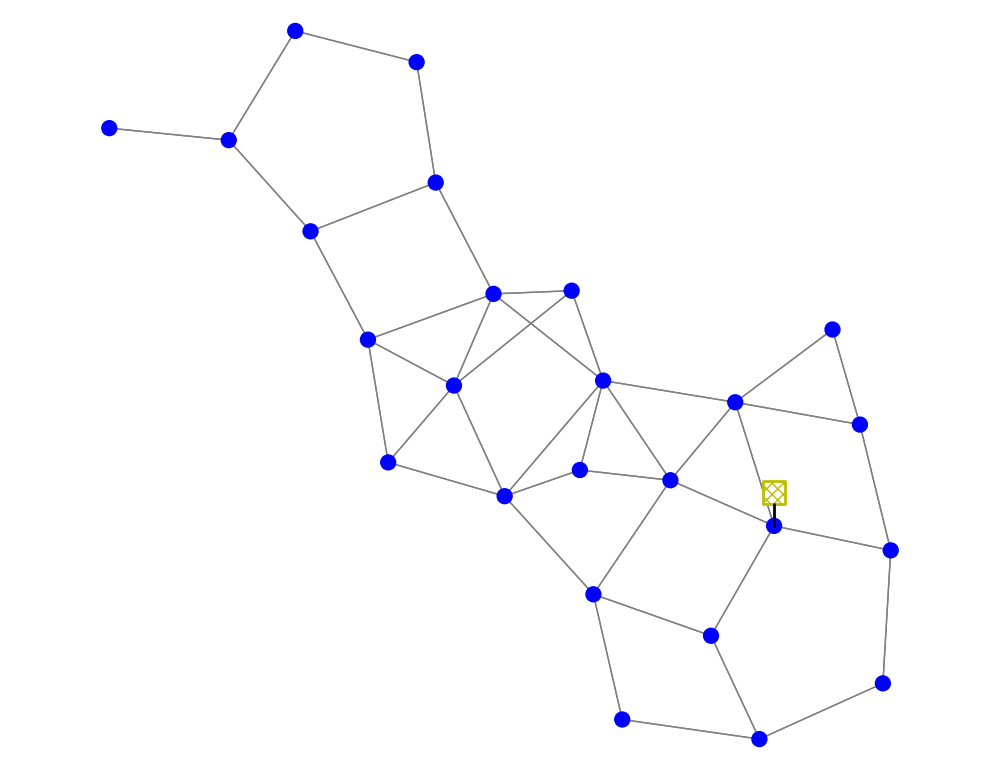

,p_mw,q_mvar
0,1098.236114,20.890673
1,1243.603041,26.332899
2,3593.678118,299.588005
3,3434.948607,-20.658503
4,108.028363,18.921384


In [486]:
#run power flow simulation
pp.runpp(net)
print("Power flow simulation completed.")
# check results
print("Load results:")

#plot power flow map    
simple_plot(net)
display(net.res_load.head())

In [487]:
# Diagnostic: check network completeness before running power flow
import networkx as nx

print("=== NETWORK DIAGNOSTIC ===")
print(f"Buses: {len(net.bus)}")
print(f"Lines: {len(net.line)}")
print(f"Loads: {len(net.load)}")
print(f"Static Generators (sgen): {len(net.sgen)}")
print(f"External Grid (slack): {len(net.ext_grid)}")

# Check for required components
if len(net.ext_grid) == 0:
    print("ERROR: No slack bus (ext_grid) found!")
if len(net.load) == 0:
    print("WARNING: No loads defined")
if len(net.sgen) == 0:
    print("WARNING: No generators defined")

# Check network connectivity using pandapower's connectivity check
try:
    from pandapower.topology import connected_components
    cc = list(connected_components(net))
    print(f"\nConnected components: {len(cc)}")
    if len(cc) > 1:
        print("WARNING: Network is disconnected! Components sizes:", [len(c) for c in cc])
    else:
        print("✓ Network is fully connected")
except Exception as e:
    print(f"Could not check connectivity: {e}")

# Check line impedance sanity
print("\nLine impedance ranges:")
print(f"  r_ohm_per_km: {net.line['r_ohm_per_km'].min():.6f} to {net.line['r_ohm_per_km'].max():.6f}")
print(f"  x_ohm_per_km: {net.line['x_ohm_per_km'].min():.6f} to {net.line['x_ohm_per_km'].max():.6f}")

# Check for very short lines (< 0.1 km) which might cause numerical issues
short_lines = net.line[net.line['length_km'] < 0.1]
if len(short_lines) > 0:
    print(f"\nWARNING: Found {len(short_lines)} very short lines (< 0.1 km)")

print("\nReady to run power flow.")

=== NETWORK DIAGNOSTIC ===
Buses: 25
Lines: 84
Loads: 25
Static Generators (sgen): 25
External Grid (slack): 1
Could not check connectivity: 'pandapowerNet' instance has no attribute 'nodes'

Line impedance ranges:
  r_ohm_per_km: 0.000359 to 0.025525
  x_ohm_per_km: 0.000743 to 0.547081

Ready to run power flow.


Copilot Plot

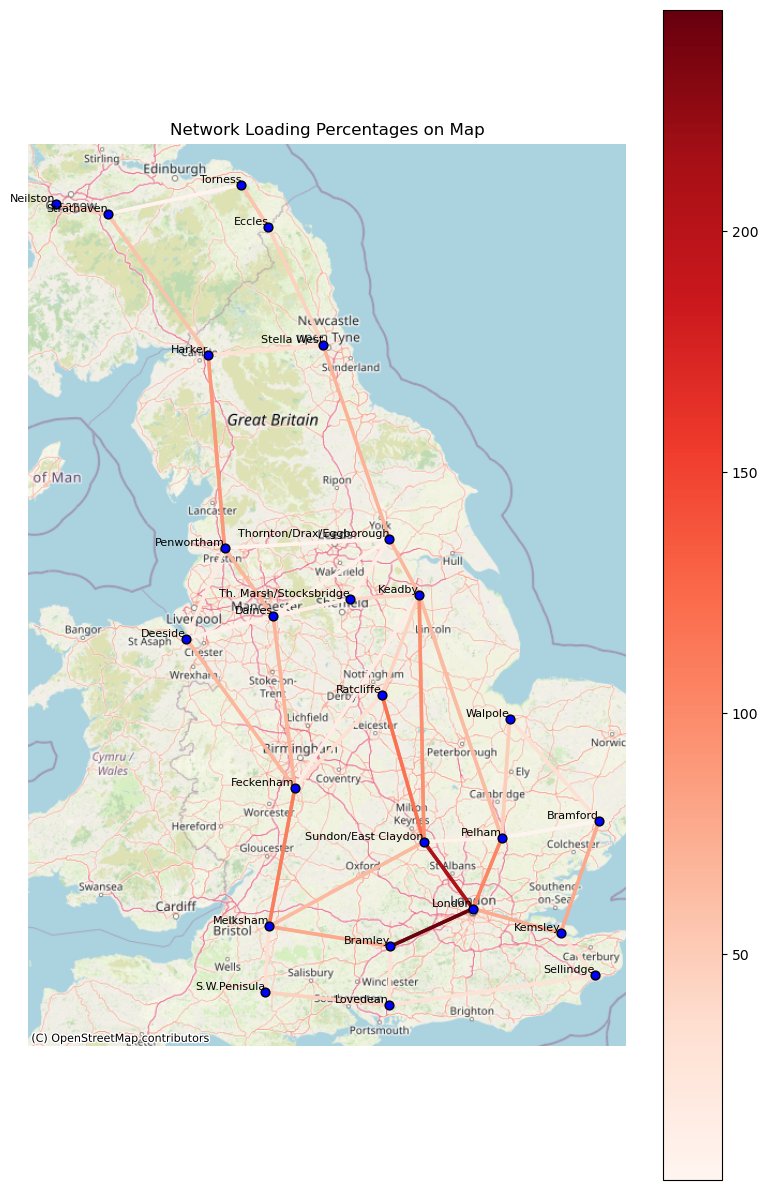

In [488]:

import contextily as ctx
from shapely.geometry import Point, LineString  

# build GeoDataFrame of bus points (assumes net.bus_geodata has longitude/latitude)
bus_idx = net.bus_geodata.index     
lon = net.bus_geodata.loc[bus_idx, "longitude"].astype(float)
lat = net.bus_geodata.loc[bus_idx, "latitude"].astype(float)
gdf_buses = gpd.GeoDataFrame(
    net.bus.loc[bus_idx, ["name", "vn_kv"]].copy(),
    geometry=gpd.points_from_xy(lon, lat),
    crs="EPSG:4326"
)   
# build GeoDataFrame of lines as LineString using bus coords
lines_geoms = []    
line_props = []
for _, line in net.line.iterrows():    
    fb = int(line["from_bus"])    
    tb = int(line["to_bus"])    
    lon1, lat1 = float(net.bus_geodata.loc[fb, "longitude"]), float(net.bus_geodata.loc[fb, "latitude"])    
    lon2, lat2 = float(net.bus_geodata.loc[tb, "longitude"]), float(net.bus_geodata.loc[tb, "latitude"])    
    lines_geoms.append(LineString([(lon1, lat1), (lon2, lat2)]))    
    line_props.append({    
        "length_km": float(line.get("length_km", 0)),    
        "r_ohm_per_km": float(line.get("r_ohm_per_km", 0)),    
        "loading_percent": float(net.res_line.loc[line.name, "loading_percent"])  # add loading percent from results    
    })
gdf_lines = gpd.GeoDataFrame(line_props, geometry=lines_geoms, crs="EPSG:4326")
# convert both to Web Mercator for basemap  
gdf_buses = gdf_buses.to_crs(epsg=3857)  
gdf_lines = gdf_lines.to_crs(epsg=3857)
# plotting  
fig, ax = plt.subplots(figsize=(8, 12)) 
# draw lines with a colormap based on loading percent
gdf_lines.plot(ax=ax, column="loading_percent", linewidth=2.5, cmap="Reds", legend=True, alpha=0.9)
# draw bus points and labels
gdf_buses.plot(ax=ax, color="blue", markersize=40, edgecolor="black", zorder=3)
# add labels (use projected coords)
for x, y, label in zip(gdf_buses.geometry.x, gdf_buses.geometry.y, gdf_buses["name"]):
    ax.text(x, y, label, fontsize=8, ha="right", va="bottom", color="black")
# add basemap (choose provider you like)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)  # or ctx.providers.OpenStreetMap.Mapnik
ax.set_axis_off()
ax.set_title("Network Loading Percentages on Map")      
plt.tight_layout()


Copilot Chat Plot

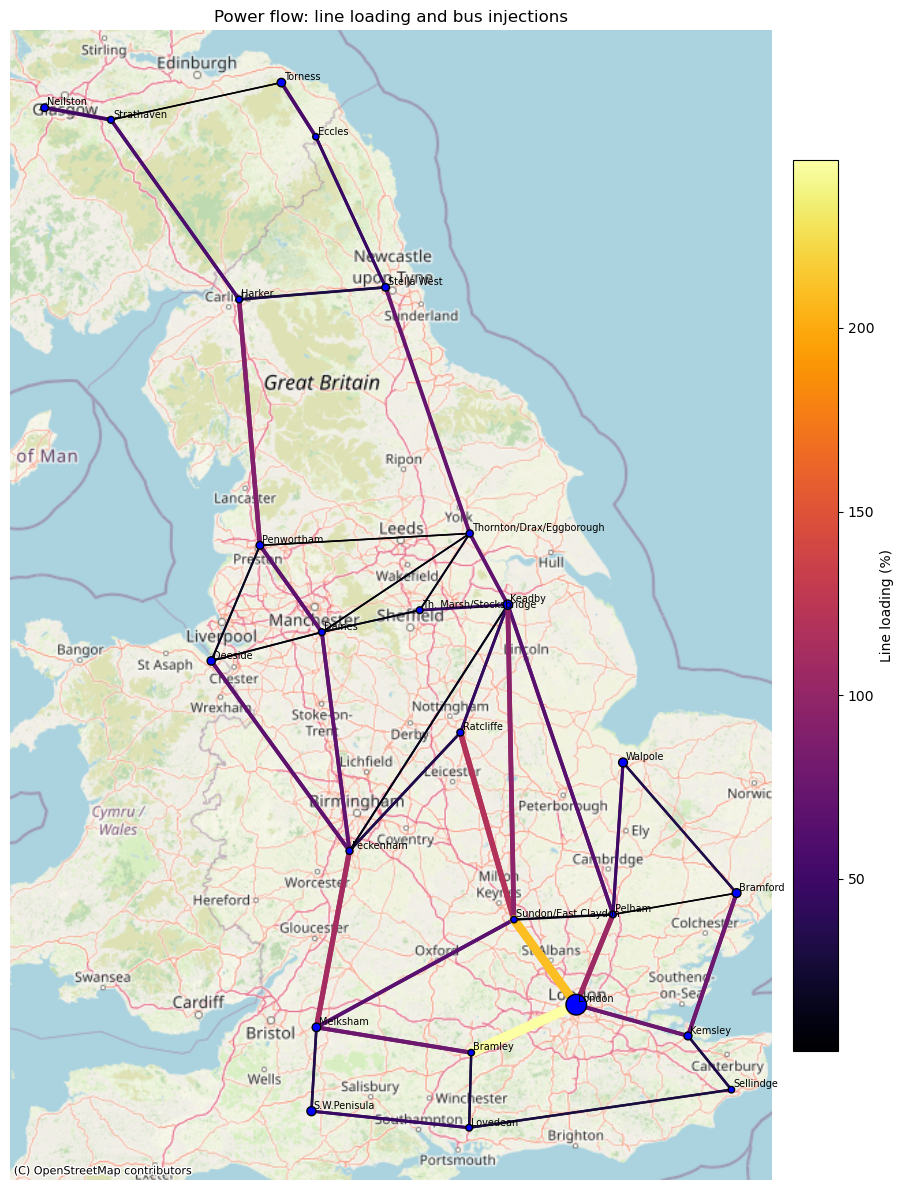

Buses (sample):


,longitude,latitude,name,vn_kv,geometry,p_mw_bus
bus,,,,,,
0,1.159651,52.088738,Bramford,400.0,POINT (1.15965 52.08874),-6926.325886
1,-0.978219,51.291877,Bramley,400.0,POINT (-0.97822 51.29188),-596.849959
2,-2.181395,53.361456,Daines,400.0,POINT (-2.1814 53.36146),1206.634118
3,-3.072208,53.223030,Deeside,400.0,POINT (-3.07221 53.22303),-5611.667393
4,-2.229827,55.677255,Eccles,400.0,POINT (-2.22983 55.67725),-111.479637


Lines (sample):


,index,from_bus,to_bus,loading,geometry
0,0,0,8,77.654530,"LINESTRING (1.15965 52.08874, 0.76818 51.37601)"
1,1,0,8,77.654530,"LINESTRING (1.15965 52.08874, 0.76818 51.37601)"
2,2,0,24,23.277113,"LINESTRING (1.15965 52.08874, 0.24497 52.73048)"
3,3,0,24,34.489477,"LINESTRING (1.15965 52.08874, 0.24497 52.73048)"
4,4,1,10,29.168660,"LINESTRING (-0.97822 51.29188, -0.99502 50.91205)"


In [489]:
# Plot power flow results on geographic map using GeoPandas + Matplotlib + contextily
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import LineString
import pandas as pd

# Verify runpp results exist
if not hasattr(net, 'res_line') or net.res_line is None or net.res_line.shape[0] == 0:
    raise RuntimeError('No line results found in net.res_line — run pp.runpp(net) first')

# Build buses GeoDataFrame from net.bus_geodata and net.bus
buses = net.bus_geodata.copy()
buses = buses.astype({'longitude': float, 'latitude': float})
buses['name'] = net.bus['name'].values
buses['vn_kv'] = net.bus['vn_kv'].values
buses['geometry'] = gpd.points_from_xy(buses['longitude'], buses['latitude'])
gdf_buses = gpd.GeoDataFrame(buses, geometry='geometry', crs='EPSG:4326')

# Attach bus results if available
if hasattr(net, 'res_bus') and net.res_bus is not None and net.res_bus.shape[0] > 0:
    resb = net.res_bus.copy()
    resb['bus'] = resb.index
    # unify active power column
    if 'p_mw' in resb.columns:
        resb['p_mw_bus'] = resb['p_mw']
    elif 'p_kw' in resb.columns:
        resb['p_mw_bus'] = resb['p_kw'] / 1000.0
    else:
        resb['p_mw_bus'] = 0.0
    gdf_buses = gdf_buses.merge(resb[['bus', 'p_mw_bus']], left_index=True, right_on='bus', how='left')
    gdf_buses = gdf_buses.set_index('bus')
else:
    gdf_buses['p_mw_bus'] = 0.0

# Build lines GeoDataFrame with loading info
lines_geoms = []
line_props = []
for idx, row in net.line.iterrows():
    fb = int(row['from_bus'])
    tb = int(row['to_bus'])
    lon1, lat1 = float(net.bus_geodata.loc[fb, 'longitude']), float(net.bus_geodata.loc[fb, 'latitude'])
    lon2, lat2 = float(net.bus_geodata.loc[tb, 'longitude']), float(net.bus_geodata.loc[tb, 'latitude'])
    lines_geoms.append(LineString([(lon1, lat1), (lon2, lat2)]))
    # extract loading percent if available
    loading = 0.0
    if hasattr(net, 'res_line') and 'loading_percent' in net.res_line.columns:
        loading = float(net.res_line.loc[idx, 'loading_percent'])
    elif hasattr(net, 'res_line') and 'loading' in net.res_line.columns:
        loading = float(net.res_line.loc[idx, 'loading'])
    line_props.append({'index': int(idx), 'from_bus': fb, 'to_bus': tb, 'loading': loading})

gdf_lines = gpd.GeoDataFrame(line_props, geometry=lines_geoms, crs='EPSG:4326')

# Project to Web Mercator for basemap plotting
gdf_buses_3857 = gdf_buses.to_crs(epsg=3857)
gdf_lines_3857 = gdf_lines.to_crs(epsg=3857)

# Prepare colormap and normalization for line loading
vmin = gdf_lines_3857['loading'].min() if not gdf_lines_3857['loading'].isna().all() else 0.0
vmax = gdf_lines_3857['loading'].max() if not gdf_lines_3857['loading'].isna().all() else 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.inferno

fig, ax = plt.subplots(figsize=(12, 12))

# Plot lines individually so linewidth can reflect loading
for _, r in gdf_lines_3857.iterrows():
    val = 0.0 if pd.isna(r['loading']) else r['loading']
    color = cmap(norm(val))
    lw = 1.0 + (val / (vmax if vmax>0 else 1.0)) * 6.0  # scale linewidth
    xs, ys = r.geometry.xy
    ax.plot(xs, ys, color=color, linewidth=lw, solid_capstyle='round', zorder=2)

# Add colorbar for loading
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('Line loading (%)')

# Plot buses sized by bus active power (p_mw_bus)
size_series = gdf_buses_3857['p_mw_bus'].abs().fillna(0.0)
if size_series.max() > 0:
    sizes = 20 + (size_series / size_series.max()) * 200
else:
    sizes = 50

gdf_buses_3857.plot(ax=ax, color='blue', markersize=sizes, zorder=3, edgecolor='k')

# Label buses (optional: show only major ones)
for idx, r in gdf_buses_3857.iterrows():
    ax.text(r.geometry.x + 2000, r.geometry.y + 2000, str(r['name']), fontsize=7, zorder=4)

# Add basemap, Open stret map
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title('Power flow: line loading and bus injections')
plt.tight_layout()
plt.show()

# Show sample tables for verification
print('Buses (sample):')
display(gdf_buses.head())
print('Lines (sample):')
display(gdf_lines.head())

In [490]:
# totals
total_load_mw = net.load['p_mw'].sum() if 'load' in net else 0.0
total_sgen_mw = net.sgen['p_mw'].sum() if 'sgen' in net else 0.0
total_gen_mw = net.gen['p_mw'].sum() if 'gen' in net else 0.0
total_ext_grid_mw = net.res_ext_grid['p_mw'].sum() if 'res_ext_grid' in net and len(net.res_ext_grid)>0 else None

print("loads (MW):", total_load_mw)
print("sgen (MW):", total_sgen_mw)
print("gens (MW):", total_gen_mw)
print("external grid injections (MW) after runpp (if available):", total_ext_grid_mw)


loads (MW): 55635.99326725187
sgen (MW): 118971.323
gens (MW): 0.0
external grid injections (MW) after runpp (if available): -62824.95902358251


In [491]:
import numpy as np


def report_pf(net, title="Scenario"):
    # run powerflow (use 'auto' options as needed)
    import pandapower as pp
    pp.runpp(net, algorithm='nr')  # use Newton-Raphson for robustness; try init='dc' if problems

    # bus voltages
    bus_res = net.res_bus[['vm_pu', 'va_degree']].copy()
    bus_res['bus_name'] = net.bus['name'].values
    bus_res = bus_res.reset_index().rename(columns={'index':'bus_idx'})

    # line loading & flows
    line_res = net.res_line[['loading_percent', 'pl_mw', 'ql_mvar']].copy()
    line_res['from_bus'] = net.line['from_bus'].values
    line_res['to_bus']   = net.line['to_bus'].values
    line_res = line_res.reset_index().rename(columns={'index':'line_idx'})

    # totals
    total_loss_mw = net.res_line.pl_mw.sum()  # approximate line losses (MW)

    # top problem buses and lines
    low_volts = bus_res[bus_res.vm_pu < 0.90].sort_values('vm_pu')
    high_volts = bus_res[bus_res.vm_pu > 1.10].sort_values('vm_pu', ascending=False)
    overloaded_lines = line_res[line_res.loading_percent > 100].sort_values('loading_percent', ascending=False)

    out = {
        'title': title,
        'bus_res': bus_res,
        'low_volts': low_volts,
        'high_volts': high_volts,
        'line_res': line_res,
        'overloaded_lines': overloaded_lines,
        'total_loss_mw': total_loss_mw
    }
    return out

def show_report(out, topn_buses=10, topn_lines=10):
    print("===", out['title'], "===\n")
    print("Total line losses (MW): {:.3f}\n".format(out['total_loss_mw']))
    print("Bus voltages (sample top {} by deviation):".format(topn_buses))
    # sort by deviation from 1.0
    out['bus_res']['dev'] = np.abs(out['bus_res'].vm_pu - 1.0)
    display(out['bus_res'].sort_values('dev', ascending=False).head(topn_buses))
    print("\nTop loaded lines (by loading %):")
    display(out['line_res'].sort_values('loading_percent', ascending=False).head(topn_lines))
    if not out['overloaded_lines'].empty:
        print("\n*** OVERLOADED LINES (>100%) ***")
        display(out['overloaded_lines'])
    if not out['low_volts'].empty:
        print("\n*** BUSES BELOW 0.90 pu ***")
        display(out['low_volts'])
    if not out['high_volts'].empty:
        print("\n*** BUSES ABOVE 1.10 pu ***")
        display(out['high_volts'])
    print("\n")


In [492]:
# store original values so we can restore
orig_loads_p = net.load['p_mw'].copy()
orig_sgen_p = None
if 'sgen' in net and len(net.sgen)>0:
    orig_sgen_p = net.sgen['p_mw'].copy()
if 'gen' in net and len(net.gen)>0:
    orig_gen_p = net.gen['p_mw'].copy()

# set loads to peak from bus_df. Ensure bus indices match (here bus index mapping assumed to be 0..N-1)
for i, r in buses_df.reset_index().iterrows():
    try:
        # find load entries assigned to bus i
        idxs = net.load[net.load.bus == i].index
        net.load.loc[idxs, 'p_mw'] = float(r['peak_demand_MW'])/1e3  # pandapower p_mw is in MW
    except Exception:
        pass

# set renewables to typical (e.g. 0.3 * nameplate) if you have nameplate in net.sgen
if orig_sgen_p is not None:
    net.sgen['p_mw'] = 0.3 * orig_sgen_p

out_peak_demand = report_pf(net, title='Peak demand (2025)')
show_report(out_peak_demand)


=== Peak demand (2025) ===

Total line losses (MW): 33.637

Bus voltages (sample top 10 by deviation):


,bus_idx,vm_pu,va_degree,bus_name,dev
23,23,1.016188,-1.339786,Torness,0.016188
4,4,1.016109,-1.339090,Eccles,0.016109
18,18,1.012556,-1.490301,Stella West,0.012556
19,19,1.011692,-1.769234,Strathaven,0.011692
12,12,1.011535,-1.829370,Neilston,0.011535
6,6,1.011155,-1.668770,Harker,0.011155
22,22,1.009291,-1.389661,Thornton/Drax/Eggborough,0.009291
21,21,1.008984,-1.481458,Th. Marsh/Stocksbridge,0.008984
14,14,1.008514,-1.564840,Penwortham,0.008514
7,7,1.007886,-1.161189,Keadby,0.007886



Top loaded lines (by loading %):


,line_idx,loading_percent,pl_mw,ql_mvar,from_bus,to_bus
5,5,54.191855,1.748070,-43.251611,1,9
6,6,54.191855,1.748070,-43.251611,1,9
71,71,46.203333,2.312019,-58.174787,20,9
70,70,46.166758,2.512859,-54.358415,20,9
23,23,44.075032,2.596609,-61.875485,5,11
22,22,44.039373,3.045231,-76.263869,5,11
72,72,42.330329,0.787726,-20.189306,20,13
58,58,41.129384,1.495732,-70.799261,15,20
59,59,41.128109,1.517508,-70.963780,15,20
75,75,33.410956,0.630013,-27.548670,21,7


In [493]:
print(net.bus_geodata.head())
print(net.line.head())

   longitude   latitude
0   1.159651  52.088738
1  -0.978219  51.291877
2  -2.181395  53.361456
3  -3.072208  53.223030
4  -2.229827  55.677255
   name std_type  from_bus  to_bus  length_km  r_ohm_per_km  x_ohm_per_km  \
0  None     None         0       8  83.711200      0.001003      0.006594   
1  None     None         0       8  83.711200      0.001003      0.006594   
2  None     None         0      24  94.556827      0.004518      0.054063   
3  None     None         0      24  94.556827      0.003350      0.036296   
4  None     None         1      10  42.251060      0.003863      0.039762   

   c_nf_per_km  g_us_per_km  max_i_ka   df  parallel  type  in_service   geo  
0     5.344856          0.0      4.01  1.0         2  None        True  None  
1     5.344856          0.0      4.01  1.0         2  None        True  None  
2    14.058653          0.0      2.29  1.0         2  None        True  None  
3     7.692074          0.0      2.29  1.0         2  None        True  None 

In [494]:
demand_dataframe_2030 = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_2030.xlsm"), sheet_name="MAIN DATA", skiprows=14, index_col=0)  # Demand by region
gsp_info_dataframe = pd.read_excel(os.path.join(DATA_DIR, "FES-2025_Regional-electricity-demand-breakdown_2030.xlsm"), sheet_name="GSP info", skiprows=4, index_col=0)  # Coordinates of GSP region


c:\Users\catz0911\AppData\Local\miniforge3\envs\GeoPower\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


In [495]:

merged_load_and_demand_2030 = gsp_info_dataframe.merge(
    demand_dataframe_2030,
    left_on="GSP ID",
    right_on="Elexon ID",
    how="inner"
)

merged_load_and_demand_2030.head()


,GSP ID,GSP Group,Minor FLOP_x,Name_x,Latitude,Longitude,Comments,Name_y,Minor FLOP_y,Major FLOP,P(Gross),Q Gross,Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Embedded Other,Dx Storage Demand,Micro storage Demand
0,ABHA1,_L,F6,Abham,50.471559,-3.729489,NaN,Abham,F6,F,343.269276,0.881963,-20.86312,193.284,425.706,1.18,1.917,81.508,0,0
1,ABNE_P,_P,T4,Abernethy,56.339456,-3.293751,NaN,Abernethy,T4,T,39.137423,-0.713455,-2.037121,1.221,44.754,31.436,0.129,7.089,0,0
2,ABTH_1,_K,H2,Aberthaw,51.385210,-3.403318,NaN,Aberthaw,H2,H,184.65653,8.827367,-32.555002,2.765,133.452,0.651,0,33.659,0,0
3,ACTL_2,_H,A7,Acton Lane 66kV,51.534951,-0.257050,NaN,Acton Lane 66kV,A7,A,26.295635,-2.139425,-2.665124,0.727,14.017,0,0.279,0.868,0,0
4,ACTL_C,_C,A7,Acton Lane 22kV,51.534951,-0.257050,NaN,Acton Lane 22kV,A7,A,36.436482,0.465031,-3.784506,0,4.24,0,0,2.041,0,0


In [496]:
merged_load_and_demand_2030.shape


(376, 20)

In [497]:
total_demand_mw = merged_load_and_demand_2030["P(Gross)"].sum()
print(f"Total demand (MW): {total_demand_mw}")

Total demand (MW): 57793.346604851205


In [498]:
# Build GSP→Closest Bus dataframe for 2030 with requested columns

# Preconditions
if 'merged_load_and_demand_2030' not in globals():
    raise RuntimeError('merged_load_and_demand_2030 not found')
if 'buses_df' not in globals():
    raise RuntimeError('buses_df not found')

# Ensure we have Closest_Bus for each GSP; compute if missing
need_nearest = ('Closest_Bus' not in merged_load_and_demand_2030.columns)
if need_nearest:
    print("Computing nearest bus for each GSP in 2030 data...")
    gdf_buses = gpd.GeoDataFrame(buses_df.copy(), geometry=gpd.points_from_xy(buses_df.longitude, buses_df.latitude), crs='EPSG:4326').to_crs(epsg=27700)
    gsp_gdf = merged_load_and_demand_2030.copy()
    if 'geometry' not in gsp_gdf.columns:
        gsp_gdf = gpd.GeoDataFrame(gsp_gdf, geometry=gpd.points_from_xy(gsp_gdf.Longitude, gsp_gdf.Latitude), crs='EPSG:4326')
    gsp_proj = gsp_gdf.to_crs(epsg=27700)
    buses_for_join = gdf_buses[['name','geometry']].rename(columns={'name':'Closest_Bus'})
    nearest = gpd.sjoin_nearest(gsp_proj, buses_for_join, how='left', distance_col='Closest_Bus_dist_m')
    nearest = nearest.reset_index(drop=True)
    if 'GSP ID' not in nearest.columns:
        nearest = nearest.reset_index()
    merged_load_and_demand_2030 = merged_load_and_demand_2030.merge(
        nearest[['GSP ID','Closest_Bus','Closest_Bus_dist_m']], on='GSP ID', how='left'
    )

# Column pickers (robust to slight name variations)
def pick(df, options, required=True):
    for o in options:
        if o in df.columns:
            return o
    # case-insensitive fallback
    lower = {c.lower(): c for c in df.columns}
    for o in options:
        if o.lower() in lower:
            return lower[o.lower()]
    if required:
        raise KeyError(f"None of the columns found: {options}")
    return None

p_col   = pick(merged_load_and_demand_2030, ['P(Gross)','P Gross','P_gross','P'])
q_col   = pick(merged_load_and_demand_2030, ['Q net','Q Net','Q_net','Q Gross','Q'])
stor_col= pick(merged_load_and_demand_2030, ['Embedded Storage','Embedded storage','Storage'], required=False)
sol_col = pick(merged_load_and_demand_2030, ['Embedded Solar','Embedded solar','Solar'], required=False)
win_col = pick(merged_load_and_demand_2030, ['Embedded Wind','Embedded wind','Wind'], required=False)
hyd_col = pick(merged_load_and_demand_2030, ['Embedded Hydro','Embedded hydro','Hydro'], required=False)

# Build output dataframe with requested columns
out_cols = {
    'GSP ID': 'GSP ID',
    p_col: 'P(Gross)',
    q_col: 'Q net',
}
if stor_col: out_cols[stor_col] = 'Embedded Storage'
if sol_col:  out_cols[sol_col]  = 'Embedded Solar'
if win_col:  out_cols[win_col]  = 'Embedded Wind'
if hyd_col:  out_cols[hyd_col]  = 'Embedded Hydro'

if 'Closest_Bus' in merged_load_and_demand_2030.columns:
    out_cols['Closest_Bus'] = 'Closest_Bus'
else:
    raise KeyError('Closest_Bus not present or could not be computed')

gsp_bus_df_2030 = merged_load_and_demand_2030[list(out_cols.keys())].rename(columns=out_cols).copy()

# Coerce numerics for numeric fields
for c in ['P(Gross)','Q net','Embedded Storage','Embedded Solar','Embedded Wind','Embedded Hydro']:
    if c in gsp_bus_df_2030.columns:
        gsp_bus_df_2030[c] = pd.to_numeric(gsp_bus_df_2030[c], errors='coerce').fillna(0)

print('Created gsp_bus_df_2030 with requested columns:')
print(list(gsp_bus_df_2030.columns))
display(gsp_bus_df_2030.head(20))

Computing nearest bus for each GSP in 2030 data...
Created gsp_bus_df_2030 with requested columns:
['GSP ID', 'P(Gross)', 'Q net', 'Embedded Storage', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Closest_Bus']


,GSP ID,P(Gross),Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Closest_Bus
0,ABHA1,343.269276,-20.863120,193.284,425.706,1.180,1.917,S.W.Penisula
1,ABNE_P,39.137423,-2.037121,1.221,44.754,31.436,0.129,Torness
2,ABTH_1,184.656530,-32.555002,2.765,133.452,0.651,0.000,Melksham
3,ACTL_2,26.295635,-2.665124,0.727,14.017,0.000,0.279,London
4,ACTL_C,36.436482,-3.784506,0.000,4.240,0.000,0.000,London
5,ALNE_P,32.059620,-2.388182,0.453,16.451,8.704,6.768,Neilston
6,ALST_3,0.000000,0.000000,0.000,7.780,0.000,0.000,Melksham
7,ALVE1,274.931049,0.841740,83.549,589.337,258.881,2.486,S.W.Penisula
8,AMEM_1,36.166293,19.587684,113.631,122.898,0.008,0.000,Sundon/East Claydon
9,ARBR_P,23.015273,-2.147363,11.203,36.153,0.923,0.000,Torness


In [499]:
# Aggregate demand and embedded resources by Closest_Bus with "Bus" prefix naming

# Determine which dataframe to use
data_to_agg = merged_load_and_demand_2030 

# Ensure Closest_Bus exists; compute if missing
if 'Closest_Bus' not in data_to_agg.columns:
    print("Computing nearest bus for each GSP...")
    gdf_buses = gpd.GeoDataFrame(buses_df.copy(), geometry=gpd.points_from_xy(buses_df.longitude, buses_df.latitude), crs='EPSG:4326').to_crs(epsg=27700)
    gsp_gdf = data_to_agg.copy()
    if 'geometry' not in gsp_gdf.columns:
        gsp_gdf = gpd.GeoDataFrame(gsp_gdf, geometry=gpd.points_from_xy(gsp_gdf.Longitude, gsp_gdf.Latitude), crs='EPSG:4326')
    gsp_proj = gsp_gdf.to_crs(epsg=27700)
    buses_for_join = gdf_buses[['name','geometry']].rename(columns={'name':'Closest_Bus'})
    nearest = gpd.sjoin_nearest(gsp_proj, buses_for_join, how='left', distance_col='dist_m')
    nearest = nearest.reset_index(drop=True)
    if 'GSP ID' not in nearest.columns:
        nearest = nearest.reset_index()
    data_to_agg = data_to_agg.merge(nearest[['GSP ID','Closest_Bus']], on='GSP ID', how='left')

# Column picker helper
def pick(df, options, required=True):
    for o in options:
        if o in df.columns:
            return o
    lower = {c.lower(): c for c in df.columns}
    for o in options:
        if o.lower() in lower:
            return lower[o.lower()]
    if required:
        raise KeyError(f"None of columns found: {options}")
    return None

# Locate columns in the dataframe
p_col      = pick(data_to_agg, ['P(Gross)', 'P Gross', 'P_gross', 'P'])
q_col      = pick(data_to_agg, ['Q net', 'Q Net', 'Q_net', 'Q Gross', 'Q'])
stor_col   = pick(data_to_agg, ['Embedded Storage', 'Embedded storage', 'Storage'], required=False)
sol_col    = pick(data_to_agg, ['Embedded Solar', 'Embedded solar', 'Solar'], required=False)
win_col    = pick(data_to_agg, ['Embedded Wind', 'Embedded wind', 'Wind'], required=False)
hyd_col    = pick(data_to_agg, ['Embedded Hydro', 'Embedded hydro', 'Hydro'], required=False)

# Coerce numeric for all columns
for col in [p_col, q_col, stor_col, sol_col, win_col, hyd_col]:
    if col is not None:
        data_to_agg[col] = pd.to_numeric(data_to_agg[col], errors='coerce').fillna(0)

# Build aggregation mapping
agg_dict = {p_col: 'sum', q_col: 'sum'}
if stor_col: agg_dict[stor_col] = 'sum'
if sol_col:  agg_dict[sol_col]  = 'sum'
if win_col:  agg_dict[win_col]  = 'sum'
if hyd_col:  agg_dict[hyd_col]  = 'sum'

# Group by Closest_Bus and sum
bus_aggregates_df = data_to_agg.groupby('Closest_Bus').agg(agg_dict).reset_index()

# Rename columns with "Bus " prefix
rename_map = {
    p_col: 'P(Gross)',
    q_col: 'Q net'
}
if stor_col: rename_map[stor_col] = 'Embedded Storage'
if sol_col:  rename_map[sol_col]  = 'Embedded Solar'
if win_col:  rename_map[win_col]  = 'Embedded Wind'
if hyd_col:  rename_map[hyd_col]  = 'Embedded Hydro'

bus_aggregates_df = bus_aggregates_df.rename(columns=rename_map)

# Rename Closest_Bus to bus name for clarity
bus_aggregates_df = bus_aggregates_df.rename(columns={'Closest_Bus': 'Bus name'})

# Reorder columns with Bus name first
cols_ordered = ['Bus name'] + [c for c in bus_aggregates_df.columns if c != 'Bus name']
bus_aggregates_df = bus_aggregates_df[cols_ordered]

# Ensure all numeric columns are float
for col in bus_aggregates_df.columns:
    if col != 'Bus name':
        bus_aggregates_df[col] = pd.to_numeric(bus_aggregates_df[col], errors='coerce').fillna(0)

print('Created bus_aggregates_df with Bus prefix columns:')
print(list(bus_aggregates_df.columns))
print(f'\nShape: {bus_aggregates_df.shape}')
display(bus_aggregates_df.head(20))




Created bus_aggregates_df with Bus prefix columns:


['Bus name', 'P(Gross)', 'Q net', 'Embedded Storage', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro']

Shape: (25, 7)


,Bus name,P(Gross),Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro
0,Bramford,1143.228559,-219.595268,411.029,1553.853,189.962,0.024
1,Bramley,1292.310750,-228.056953,119.689,507.125,0.704,0.422
2,Daines,3665.384273,-122.265932,772.365,802.240,203.754,3.240
3,Deeside,3567.190651,-427.785896,545.754,1621.201,1273.996,20.147
4,Eccles,116.320779,3.481341,5.105,58.017,251.449,0.509
5,Feckenham,4378.913592,-302.555226,1131.836,2178.424,221.889,0.763
6,Harker,576.824399,4.377165,66.028,249.451,411.964,47.156
7,Keadby,1082.332229,-28.305852,457.598,871.702,332.559,0.000
8,Kemsley,1484.175327,-184.612984,555.834,1121.858,161.570,0.046
9,London,9403.905325,-720.190017,220.516,1237.094,3.149,3.876


In [500]:
gens_df

,Name,Fueltype,Technology,Capacity (MW),lat,lon,Closest_Bus,Distance_to_Bus_m
id,,,,,,,,
37,Sloy,Hydro,Run-Of-River,153.0,56.26150,-4.76360,Neilston,54888.977694
38,Foye,Hydro,Run-Of-River,320.0,57.25580,-4.49410,Neilston,161182.599082
39,Ffes,Hydro,Run-Of-River,384.0,52.98080,-3.96860,Deeside,65796.850708
40,Dino,Hydro,Run-Of-River,1728.0,53.12060,-4.11530,Deeside,70660.267677
41,Crua,Hydro,Pumped Storage,440.0,56.41920,-5.01270,Neilston,77472.371603
...,...,...,...,...,...,...,...,...
20681,Tees Rep Biomass,Solid Biomass,Steam Turbine,299.0,54.60020,-1.15860,Stella West,54096.733091
20941,Triton Knoll Wind Farm,Wind,Offshore,857.0,53.21230,0.86160,Walpole,67757.186857
21418,Viking Wind Farm United Kingdom,Wind,Onshore,443.0,60.33930,-1.20840,Torness,497662.177112


In [501]:
# Aggregate generation capacity (MW) by closest bus and fuel type
import pandas as pd

# Ensure Closest_Bus exists in gens_df
if 'Closest_Bus' not in gens_df.columns:
    raise KeyError("Closest_Bus column not found in gens_df. Run nearest-bus assignment for generators first.")

# Coerce Capacity (MW) to numeric
gens_df_copy = gens_df.copy()
gens_df_copy['Capacity (MW)'] = pd.to_numeric(gens_df_copy['Capacity (MW)'], errors='coerce').fillna(0)

# Group by Closest_Bus and Fueltype, sum Capacity (MW)
gen_by_bus_fueltype = gens_df_copy.groupby(['Closest_Bus', 'Fueltype']).agg({'Capacity (MW)': 'sum'}).reset_index()

# Rename for clarity
gen_by_bus_fueltype = gen_by_bus_fueltype.rename(columns={'Capacity (MW)': 'Total Capacity (MW)'})

# Ensure Closest_Bus is a string and Total Capacity is numeric
gen_by_bus_fueltype['Closest_Bus'] = gen_by_bus_fueltype['Closest_Bus'].astype(str)
gen_by_bus_fueltype['Total Capacity (MW)'] = pd.to_numeric(gen_by_bus_fueltype['Total Capacity (MW)'], errors='coerce').fillna(0)

# Reorder columns
gen_by_bus_fueltype = gen_by_bus_fueltype[['Closest_Bus', 'Fueltype', 'Total Capacity (MW)']]

print(f'Created gen_by_bus_fueltype with {len(gen_by_bus_fueltype)} rows')
print(f'Unique buses: {gen_by_bus_fueltype["Closest_Bus"].nunique()}')
print(f'Unique fuel types: {gen_by_bus_fueltype["Fueltype"].nunique()}')
print(f'Total capacity: {gen_by_bus_fueltype["Total Capacity (MW)"].sum():.2f} MW')
print(f'\nColumns: {list(gen_by_bus_fueltype.columns)}')
print('\nFuel types represented:')
print(gen_by_bus_fueltype['Fueltype'].value_counts())
print('\nSample rows:')
display(gen_by_bus_fueltype.head(20))

Created gen_by_bus_fueltype with 43 rows
Unique buses: 22
Unique fuel types: 6
Total capacity: 77864.90 MW

Columns: ['Closest_Bus', 'Fueltype', 'Total Capacity (MW)']

Fuel types represented:
Fueltype
Natural Gas      20
Wind             14
Nuclear           4
Hydro             2
Solid Biomass     2
Solar             1
Name: count, dtype: int64

Sample rows:


,Closest_Bus,Fueltype,Total Capacity (MW)
0,Bramford,Natural Gas,440.0
1,Bramford,Nuclear,1320.0
2,Bramford,Wind,4585.8
3,Bramley,Natural Gas,1490.0
4,Daines,Natural Gas,1045.0
5,Deeside,Hydro,2112.0
6,Deeside,Natural Gas,2825.0
7,Deeside,Wind,830.0
8,Harker,Natural Gas,180.0
9,Harker,Wind,969.0


In [502]:
# Create new dataframe by adding fuel-type generation to bus_aggregates_df
import pandas as pd

# Start with a copy of bus_aggregates_df
bus_with_gen_types = bus_aggregates_df.copy()

# Pivot gen_by_bus_fueltype to get fuel types as columns
gen_pivot = gen_by_bus_fueltype.pivot_table(
    index='Closest_Bus',
    columns='Fueltype',
    values='Total Capacity (MW)',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Map fuel types to embedded column names
fuel_mapping = {
    'Solar': 'Embedded Solar',
    'Wind': 'Embedded Wind',
    'Hydro': 'Embedded Hydro',
    'Solid Biomass': 'Solid Biomass'
}

# Rename pivoted columns according to mapping
rename_cols = {}
for old_name, new_name in fuel_mapping.items():
    if old_name in gen_pivot.columns:
        rename_cols[old_name] = new_name

gen_pivot = gen_pivot.rename(columns=rename_cols)

# Merge with bus_aggregates_df on bus name
# bus_aggregates_df has 'Bus name', gen_pivot has 'Closest_Bus'
bus_with_gen_types = bus_with_gen_types.merge(
    gen_pivot,
    left_on='Bus name',
    right_on='Closest_Bus',
    how='left',
    suffixes=('', '_gen')
)

# Drop the redundant Closest_Bus column from merge
bus_with_gen_types = bus_with_gen_types.drop(columns=['Closest_Bus'], errors='ignore')

# Add generator values to existing embedded columns (where they exist in both dataframes)
for col_name in ['Embedded Solar', 'Embedded Wind', 'Embedded Hydro']:
    if col_name in bus_aggregates_df.columns and col_name + '_gen' in bus_with_gen_types.columns:
        # Both exist: add generator capacity to embedded capacity
        bus_with_gen_types[col_name] = (
            bus_with_gen_types[col_name].fillna(0) + 
            bus_with_gen_types[col_name + '_gen'].fillna(0)
        )
        bus_with_gen_types = bus_with_gen_types.drop(columns=[col_name + '_gen'])
    elif col_name + '_gen' in bus_with_gen_types.columns:
        # Only generator version exists: rename it
        bus_with_gen_types[col_name] = bus_with_gen_types[col_name + '_gen'].fillna(0)
        bus_with_gen_types = bus_with_gen_types.drop(columns=[col_name + '_gen'])

# Ensure Solid Biomass column exists
if 'Solid Biomass' not in bus_with_gen_types.columns:
    if 'Solid Biomass_gen' in bus_with_gen_types.columns:
        bus_with_gen_types['Solid Biomass'] = bus_with_gen_types['Solid Biomass_gen'].fillna(0)
        bus_with_gen_types = bus_with_gen_types.drop(columns=['Solid Biomass_gen'])
    else:
        bus_with_gen_types['Solid Biomass'] = 0.0

# Select and reorder final columns
final_cols = ['Bus name', 'P(Gross)', 'Q net', 'Embedded Storage', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Solid Biomass']
available_cols = [c for c in final_cols if c in bus_with_gen_types.columns]
bus_with_gen_types = bus_with_gen_types[available_cols]

# Ensure all numeric columns are float
for col in bus_with_gen_types.columns:
    if col != 'Bus name':
        bus_with_gen_types[col] = pd.to_numeric(bus_with_gen_types[col], errors='coerce').fillna(0)

print(f'Created bus_with_gen_types with {len(bus_with_gen_types)} buses')
print(f'Columns: {list(bus_with_gen_types.columns)}')

print('\nFirst 20 rows:')
display(bus_with_gen_types.head(20))

Created bus_with_gen_types with 25 buses
Columns: ['Bus name', 'P(Gross)', 'Q net', 'Embedded Storage', 'Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Solid Biomass']

First 20 rows:


,Bus name,P(Gross),Q net,Embedded Storage,Embedded Solar,Embedded Wind,Embedded Hydro,Solid Biomass
0,Bramford,1143.228559,-219.595268,411.029,1553.853,4775.762,0.024,0.0
1,Bramley,1292.310750,-228.056953,119.689,507.125,0.704,0.422,0.0
2,Daines,3665.384273,-122.265932,772.365,802.240,203.754,3.240,0.0
3,Deeside,3567.190651,-427.785896,545.754,1621.201,2103.996,2132.147,0.0
4,Eccles,116.320779,3.481341,5.105,58.017,251.449,0.509,0.0
5,Feckenham,4378.913592,-302.555226,1131.836,2178.424,221.889,0.763,0.0
6,Harker,576.824399,4.377165,66.028,249.451,1380.964,47.156,0.0
7,Keadby,1082.332229,-28.305852,457.598,871.702,1632.559,0.000,0.0
8,Kemsley,1484.175327,-184.612984,555.834,1500.158,301.570,0.046,0.0
9,London,9403.905325,-720.190017,220.516,1237.094,3.149,3.876,0.0


In [503]:
# Convert bus_with_gen_types from power (MW) to annual energy (MWh) using capacity factors
import pandas as pd

# Constants
HOURS_PER_YEAR = 8760

# Capacity factors for each resource type
CAPACITY_FACTORS = {
    'Solar': 0.11,
    'Wind': 0.33,
    'Hydro': 0.351,
    'Solid Biomass': 0.67
}

# Start with a copy of bus_with_gen_types
energy_df = bus_with_gen_types.copy()

# Drop Q net if present
energy_df = energy_df.drop(columns=['Q net'], errors='ignore')

# Ensure resource columns exist (create with zeros if missing)
resource_cols = ['Embedded Solar', 'Embedded Wind', 'Embedded Hydro', 'Solid Biomass']
for col in resource_cols:
    if col not in energy_df.columns:
        energy_df[col] = 0.0

# Convert P(Gross) to annual energy demand (MWh)
if 'P(Gross)' in energy_df.columns:
    energy_df['Annual Energy Demand (MWh)'] = energy_df['P(Gross)'] * HOURS_PER_YEAR
    energy_df = energy_df.drop(columns=['P(Gross)'])
else:
    energy_df['Annual Energy Demand (MWh)'] = 0.0

# Convert resource columns to annual energy supply (MWh) using capacity factors
if 'Embedded Solar' in energy_df.columns:
    energy_df['Solar Energy Supply (MWh)'] = energy_df['Embedded Solar'] * HOURS_PER_YEAR * CAPACITY_FACTORS['Solar']
    energy_df = energy_df.drop(columns=['Embedded Solar'])
else:
    energy_df['Solar Energy Supply (MWh)'] = 0.0

if 'Embedded Wind' in energy_df.columns:
    energy_df['Wind Energy Supply (MWh)'] = energy_df['Embedded Wind'] * HOURS_PER_YEAR * CAPACITY_FACTORS['Wind']
    energy_df = energy_df.drop(columns=['Embedded Wind'])
else:
    energy_df['Wind Energy Supply (MWh)'] = 0.0

if 'Embedded Hydro' in energy_df.columns:
    energy_df['Hydro Energy Supply (MWh)'] = energy_df['Embedded Hydro'] * HOURS_PER_YEAR * CAPACITY_FACTORS['Hydro']
    energy_df = energy_df.drop(columns=['Embedded Hydro'])
else:
    energy_df['Hydro Energy Supply (MWh)'] = 0.0

if 'Solid Biomass' in energy_df.columns:
    energy_df['Solid Biomass Energy Supplied (MWh)'] = energy_df['Solid Biomass'] * HOURS_PER_YEAR * CAPACITY_FACTORS['Solid Biomass']
    energy_df = energy_df.drop(columns=['Solid Biomass'])
else:
    energy_df['Solid Biomass Energy Supplied (MWh)'] = 0.0

# Drop Embedded Storage if present (not converted to energy)
energy_df = energy_df.drop(columns=['Embedded Storage'], errors='ignore')

# Reorder columns: Bus name first, then demand, then supply columns
final_cols = [
    'Bus name',
    'Annual Energy Demand (MWh)',
    'Solar Energy Supply (MWh)',
    'Wind Energy Supply (MWh)',
    'Hydro Energy Supply (MWh)',
    'Solid Biomass Energy Supplied (MWh)'
]
available_cols = [c for c in final_cols if c in energy_df.columns]
energy_df = energy_df[available_cols]

# Ensure all numeric columns are float
for col in energy_df.columns:
    if col != 'Bus name':
        energy_df[col] = pd.to_numeric(energy_df[col], errors='coerce').fillna(0)

# Display the dataframe
print(f'Created energy_df with {len(energy_df)} buses')
print(f'Columns: {list(energy_df.columns)}\n')
display(energy_df.head(20))

# Calculate and print summary statistics
total_solar = energy_df['Solar Energy Supply (MWh)'].sum()
total_wind = energy_df['Wind Energy Supply (MWh)'].sum()
total_hydro = energy_df['Hydro Energy Supply (MWh)'].sum()
total_biomass = energy_df['Solid Biomass Energy Supplied (MWh)'].sum()
total_demand = energy_df['Annual Energy Demand (MWh)'].sum()

total_supplied = total_solar + total_wind + total_hydro + total_biomass
net_energy = total_supplied - total_demand

print('\n' + '='*60)
print(f'Total Energy Supplied (MWh): {total_supplied:,.0f}')
print(f'Total Energy Demand (MWh): {total_demand:,.0f}')
print(f'Net Energy (MWh): {net_energy:,.0f}')
print('='*60)

Created energy_df with 25 buses
Columns: ['Bus name', 'Annual Energy Demand (MWh)', 'Solar Energy Supply (MWh)', 'Wind Energy Supply (MWh)', 'Hydro Energy Supply (MWh)', 'Solid Biomass Energy Supplied (MWh)']



,Bus name,Annual Energy Demand (MWh),Solar Energy Supply (MWh),Wind Energy Supply (MWh),Hydro Energy Supply (MWh),Solid Biomass Energy Supplied (MWh)
0,Bramford,1.001468e+07,1.497293e+06,1.380577e+07,7.379424e+01,0.0
1,Bramley,1.132064e+07,4.886657e+05,2.035123e+03,1.297549e+03,0.0
2,Daines,3.210877e+07,7.730385e+05,5.890121e+05,9.962222e+03,0.0
3,Deeside,3.124859e+07,1.562189e+06,6.082232e+06,6.555840e+06,0.0
4,Eccles,1.018970e+06,5.590518e+04,7.268888e+05,1.565053e+03,0.0
5,Feckenham,3.835928e+07,2.099129e+06,6.414367e+05,2.346042e+03,0.0
6,Harker,5.052982e+06,2.403710e+05,3.992091e+06,1.449934e+05,0.0
7,Keadby,9.481230e+06,8.399720e+05,4.719402e+06,0.000000e+00,0.0
8,Kemsley,1.300138e+07,1.445552e+06,8.717786e+05,1.414390e+02,0.0
9,London,8.237821e+07,1.192064e+06,9.103129e+03,1.191777e+04,0.0



Total Energy Supplied (MWh): 163,011,616
Total Energy Demand (MWh): 506,269,716
Net Energy (MWh): -343,258,100


In [504]:
# Add Solar-to-Wind Ratio column to energy_df
import numpy as np

# Calculate the ratio with safe division (handles zero wind energy)
energy_df['Solar-to-Wind Ratio'] = np.where(
    energy_df['Wind Energy Supply (MWh)'] != 0,
    energy_df['Solar Energy Supply (MWh)'] / energy_df['Wind Energy Supply (MWh)'],
    np.nan
)

print('Added Solar-to-Wind Ratio column to energy_df')
print(f'\nColumns: {list(energy_df.columns)}')
print(f'\nSolar-to-Wind Ratio statistics:')
print(energy_df['Solar-to-Wind Ratio'].describe())
print(f'\nBuses with valid ratios: {energy_df["Solar-to-Wind Ratio"].notna().sum()} / {len(energy_df)}')
display(energy_df.head(20))

Added Solar-to-Wind Ratio column to energy_df

Columns: ['Bus name', 'Annual Energy Demand (MWh)', 'Solar Energy Supply (MWh)', 'Wind Energy Supply (MWh)', 'Hydro Energy Supply (MWh)', 'Solid Biomass Energy Supplied (MWh)', 'Solar-to-Wind Ratio']

Solar-to-Wind Ratio statistics:
count     25.000000
mean      16.254465
std       53.378744
min        0.046305
25%        0.105190
50%        0.679981
75%        2.851174
max      240.116004
Name: Solar-to-Wind Ratio, dtype: float64

Buses with valid ratios: 25 / 25


,Bus name,Annual Energy Demand (MWh),Solar Energy Supply (MWh),Wind Energy Supply (MWh),Hydro Energy Supply (MWh),Solid Biomass Energy Supplied (MWh),Solar-to-Wind Ratio
0,Bramford,1.001468e+07,1.497293e+06,1.380577e+07,7.379424e+01,0.0,0.108454
1,Bramley,1.132064e+07,4.886657e+05,2.035123e+03,1.297549e+03,0.0,240.116004
2,Daines,3.210877e+07,7.730385e+05,5.890121e+05,9.962222e+03,0.0,1.312432
3,Deeside,3.124859e+07,1.562189e+06,6.082232e+06,6.555840e+06,0.0,0.256845
4,Eccles,1.018970e+06,5.590518e+04,7.268888e+05,1.565053e+03,0.0,0.076910
5,Feckenham,3.835928e+07,2.099129e+06,6.414367e+05,2.346042e+03,0.0,3.272543
6,Harker,5.052982e+06,2.403710e+05,3.992091e+06,1.449934e+05,0.0,0.060212
7,Keadby,9.481230e+06,8.399720e+05,4.719402e+06,0.000000e+00,0.0,0.177983
8,Kemsley,1.300138e+07,1.445552e+06,8.717786e+05,1.414390e+02,0.0,1.658164
9,London,8.237821e+07,1.192064e+06,9.103129e+03,1.191777e+04,0.0,130.950990


In [505]:
# Scale Solar and Wind together to meet energy demand
import pandas as pd

# Calculate current totals
original_solar = energy_df['Solar Energy Supply (MWh)'].sum()
original_wind = energy_df['Wind Energy Supply (MWh)'].sum()
total_hydro = energy_df['Hydro Energy Supply (MWh)'].sum()
total_biomass = energy_df['Solid Biomass Energy Supplied (MWh)'].sum()
total_demand = energy_df['Annual Energy Demand (MWh)'].sum()

# Fixed supply from non-scaled sources
fixed_supply = total_hydro + total_biomass

# Find the minimum integer multiplier needed
multiplier = 1
while True:
    scaled_solar = original_solar * multiplier
    scaled_wind = original_wind * multiplier
    total_supplied = scaled_solar + scaled_wind + fixed_supply
    
    if total_supplied >= total_demand:
        break
    multiplier += 0.5

# Calculate additional energy needed from scaling
energy_df['Additional Solar (MWh)'] = energy_df['Solar Energy Supply (MWh)'] * (multiplier - 1)
energy_df['Additional Wind (MWh)'] = energy_df['Wind Energy Supply (MWh)'] * (multiplier - 1)

# Calculate final totals
final_solar = energy_df['Solar Energy Supply (MWh)'].sum() + energy_df['Additional Solar (MWh)'].sum()
final_wind = energy_df['Wind Energy Supply (MWh)'].sum() + energy_df['Additional Wind (MWh)'].sum()
final_total_supplied = final_solar + final_wind + fixed_supply
net_energy = final_total_supplied - total_demand

# Display results
print('='*70)
print('SCALING SOLAR AND WIND TO MEET DEMAND')
print('='*70)
print(f'\nChosen multiplier: {multiplier}×')
print(f'\nOriginal totals:')
print(f'  Solar Energy Supply: {original_solar:,.0f} MWh')
print(f'  Wind Energy Supply: {original_wind:,.0f} MWh')
print(f'  Hydro Energy Supply: {total_hydro:,.0f} MWh (not scaled)')
print(f'  Solid Biomass Energy: {total_biomass:,.0f} MWh (not scaled)')
print(f'  Original Total Supply: {original_solar + original_wind + fixed_supply:,.0f} MWh')

print(f'\nScaled totals (multiplier = {multiplier}×):')
print(f'  Scaled Solar Energy: {final_solar:,.0f} MWh')
print(f'  Scaled Wind Energy: {final_wind:,.0f} MWh')
print(f'  Total Supply (with scaling): {final_total_supplied:,.0f} MWh')

print(f'\nDemand and balance:')
print(f'  Total Energy Demand: {total_demand:,.0f} MWh')
print(f'  Net Energy (Supply - Demand): {net_energy:,.0f} MWh')

print(f'\nAdditional capacity added:')
print(f'  Additional Solar: {energy_df["Additional Solar (MWh)"].sum():,.0f} MWh')
print(f'  Additional Wind: {energy_df["Additional Wind (MWh)"].sum():,.0f} MWh')
print('='*70)

print(f'\nUpdated energy_df columns: {list(energy_df.columns)}')
print(f'\nSample rows with additional capacity:')
display(energy_df[energy_df['Additional Solar (MWh)'] > 0].head(10))

SCALING SOLAR AND WIND TO MEET DEMAND

Chosen multiplier: 4.0×

Original totals:
  Solar Energy Supply: 33,630,841 MWh
  Wind Energy Supply: 100,709,352 MWh
  Hydro Energy Supply: 10,964,047 MWh (not scaled)
  Solid Biomass Energy: 17,707,376 MWh (not scaled)
  Original Total Supply: 163,011,616 MWh

Scaled totals (multiplier = 4.0×):
  Scaled Solar Energy: 134,523,363 MWh
  Scaled Wind Energy: 402,837,409 MWh
  Total Supply (with scaling): 566,032,195 MWh

Demand and balance:
  Total Energy Demand: 506,269,716 MWh
  Net Energy (Supply - Demand): 59,762,478 MWh

Additional capacity added:
  Additional Solar: 100,892,522 MWh
  Additional Wind: 302,128,057 MWh

Updated energy_df columns: ['Bus name', 'Annual Energy Demand (MWh)', 'Solar Energy Supply (MWh)', 'Wind Energy Supply (MWh)', 'Hydro Energy Supply (MWh)', 'Solid Biomass Energy Supplied (MWh)', 'Solar-to-Wind Ratio', 'Additional Solar (MWh)', 'Additional Wind (MWh)']

Sample rows with additional capacity:


,Bus name,Annual Energy Demand (MWh),Solar Energy Supply (MWh),Wind Energy Supply (MWh),Hydro Energy Supply (MWh),Solid Biomass Energy Supplied (MWh),Solar-to-Wind Ratio,Additional Solar (MWh),Additional Wind (MWh)
0,Bramford,1.001468e+07,1.497293e+06,1.380577e+07,7.379424e+01,0.0,0.108454,4.491878e+06,4.141732e+07
1,Bramley,1.132064e+07,4.886657e+05,2.035123e+03,1.297549e+03,0.0,240.116004,1.465997e+06,6.105370e+03
2,Daines,3.210877e+07,7.730385e+05,5.890121e+05,9.962222e+03,0.0,1.312432,2.319115e+06,1.767036e+06
3,Deeside,3.124859e+07,1.562189e+06,6.082232e+06,6.555840e+06,0.0,0.256845,4.686568e+06,1.824669e+07
4,Eccles,1.018970e+06,5.590518e+04,7.268888e+05,1.565053e+03,0.0,0.076910,1.677155e+05,2.180666e+06
5,Feckenham,3.835928e+07,2.099129e+06,6.414367e+05,2.346042e+03,0.0,3.272543,6.297388e+06,1.924310e+06
6,Harker,5.052982e+06,2.403710e+05,3.992091e+06,1.449934e+05,0.0,0.060212,7.211130e+05,1.197627e+07
7,Keadby,9.481230e+06,8.399720e+05,4.719402e+06,0.000000e+00,0.0,0.177983,2.519916e+06,1.415820e+07
8,Kemsley,1.300138e+07,1.445552e+06,8.717786e+05,1.414390e+02,0.0,1.658164,4.336657e+06,2.615336e+06
9,London,8.237821e+07,1.192064e+06,9.103129e+03,1.191777e+04,0.0,130.950990,3.576191e+06,2.730939e+04


In [506]:
# Create power_df: convert annual energy (MWh) to average power (MW)
import pandas as pd

HOURS_PER_YEAR = 8760
CF_SOLAR = 0.11
CF_WIND = 0.33
CF_HYDRO = 0.351
CF_BIOMASS = 0.67

# Start from a copy; do not modify energy_df
power_df = energy_df.copy()

# Ensure required columns exist, create with zeros if absent
required_cols = [
    'Annual Energy Demand (MWh)',
    'Solar Energy Supply (MWh)',
    'Wind Energy Supply (MWh)',
    'Hydro Energy Supply (MWh)',
    'Solid Biomass Energy Supplied (MWh)',
    'Additional Solar (MWh)',
    'Additional Wind (MWh)'
]
for c in required_cols:
    if c not in power_df.columns:
        power_df[c] = 0.0

# Preserve bus identifier
bus_col = None
for cand in ['Bus name','Bus','bus name','bus']:
    if cand in power_df.columns:
        bus_col = cand
        break
if bus_col is None:
    # create placeholder if missing
    power_df['Bus'] = range(len(power_df))
    bus_col = 'Bus'

# Compute average power capacities (MW)
# Demand
power_df['P (Gross) (MW)'] = pd.to_numeric(power_df['Annual Energy Demand (MWh)'], errors='coerce').fillna(0) / HOURS_PER_YEAR

# Supplies
power_df['Solar Capacity (MW)'] = pd.to_numeric(power_df['Solar Energy Supply (MWh)'], errors='coerce').fillna(0) / (HOURS_PER_YEAR * CF_SOLAR)
power_df['Wind Capacity (MW)'] = pd.to_numeric(power_df['Wind Energy Supply (MWh)'], errors='coerce').fillna(0) / (HOURS_PER_YEAR * CF_WIND)
power_df['Hydro Capacity (MW)'] = pd.to_numeric(power_df['Hydro Energy Supply (MWh)'], errors='coerce').fillna(0) / (HOURS_PER_YEAR * CF_HYDRO)
power_df['Solid Biomass Capacity (MW)'] = pd.to_numeric(power_df['Solid Biomass Energy Supplied (MWh)'], errors='coerce').fillna(0) / (HOURS_PER_YEAR * CF_BIOMASS)

# Additional capacities
power_df['Additional Solar Capacity (MW)'] = pd.to_numeric(power_df['Additional Solar (MWh)'], errors='coerce').fillna(0) / (HOURS_PER_YEAR * CF_SOLAR)
power_df['Additional Wind Capacity (MW)'] = pd.to_numeric(power_df['Additional Wind (MWh)'], errors='coerce').fillna(0) / (HOURS_PER_YEAR * CF_WIND)

# Final column order: keep bus id and exact names requested
final_cols = [
    bus_col,
    'P (Gross) (MW)',
    'Solar Capacity (MW)',
    'Wind Capacity (MW)',
    'Hydro Capacity (MW)',
    'Solid Biomass Capacity (MW)',
    'Additional Solar Capacity (MW)',
    'Additional Wind Capacity (MW)'
]
# Rename bus column to 'Bus' if not already
if bus_col != 'Bus':
    power_df = power_df.rename(columns={bus_col: 'Bus'})
    final_cols[0] = 'Bus'

power_df = power_df[final_cols]

print('Created power_df (MW capacities)')
display(power_df.head())
emand_total = 0.0
if 'P (Gross) (MW)' in power_df.columns:
    demand_total = pd.to_numeric(power_df['P (Gross) (MW)'], errors='coerce').fillna(0.0).sum()

print(f"Total demand (MW): {demand_total:,.2f}")


Created power_df (MW capacities)


,Bus,P (Gross) (MW),Solar Capacity (MW),Wind Capacity (MW),Hydro Capacity (MW),Solid Biomass Capacity (MW),Additional Solar Capacity (MW),Additional Wind Capacity (MW)
0,Bramford,1143.228559,1553.853,4775.762,0.024,0.0,4661.559,14327.286
1,Bramley,1292.310750,507.125,0.704,0.422,0.0,1521.375,2.112
2,Daines,3665.384273,802.240,203.754,3.240,0.0,2406.720,611.262
3,Deeside,3567.190651,1621.201,2103.996,2132.147,0.0,4863.603,6311.988
4,Eccles,116.320779,58.017,251.449,0.509,0.0,174.051,754.347


Total demand (MW): 57,793.35


In [507]:
# Aggregate non-renewable generation (MW) by Closest_Bus for Nuclear and Natural Gas
import pandas as pd
import numpy as np

# Work from a copy; do not modify original
if 'gen_by_bus_fueltype' not in globals():
    raise RuntimeError('gen_by_bus_fueltype not found. Create it before running this cell.')

req_cols = {'Closest_Bus', 'Fueltype', 'Total Capacity (MW)'}
missing = req_cols - set(gen_by_bus_fueltype.columns)
if missing:
    raise KeyError(f'Missing required columns in gen_by_bus_fueltype: {missing}')

src = gen_by_bus_fueltype.copy()

# Normalize fuel types (case-insensitive)
ft_norm = src['Fueltype'].astype(str).str.strip().str.lower()

# Map only desired fuels to exact output labels
mapped = np.where(ft_norm == 'nuclear', 'Nuclear',
          np.where(ft_norm == 'natural gas', 'Natural gas', np.nan))

src['fuel_mapped'] = mapped
src = src[~src['fuel_mapped'].isna()].copy()

# Aggregate capacities by Closest_Bus and mapped fuel
pivot = src.pivot_table(
    index='Closest_Bus',
    columns='fuel_mapped',
    values='Total Capacity (MW)',
    aggfunc='sum',
    fill_value=0.0
)

# Ensure both columns exist even if absent in data
for col in ['Nuclear', 'Natural gas']:
    if col not in pivot.columns:
        pivot[col] = 0.0

# Reorder and finalize
non_renewables_by_bus = pivot[['Nuclear', 'Natural gas']].reset_index()

# Display result
print('Created non_renewables_by_bus: Nuclear and Natural gas capacity (MW) by Closest_Bus')
display(non_renewables_by_bus)

Created non_renewables_by_bus: Nuclear and Natural gas capacity (MW) by Closest_Bus


fuel_mapped,Closest_Bus,Nuclear,Natural gas
0,Bramford,1320.0,440.0
1,Bramley,0.0,1490.0
2,Daines,0.0,1045.0
3,Deeside,0.0,2825.0
4,Harker,0.0,180.0
5,Keadby,0.0,7267.0
6,Kemsley,0.0,3990.0
7,London,0.0,552.0
8,Lovedean,0.0,1465.0
9,Melksham,0.0,5499.0


In [508]:
# Add Nuclear and Natural gas from non_renewables_by_bus into power_df
import pandas as pd

# Check that both source dataframes exist
if 'power_df' not in globals():
    raise RuntimeError('power_df not found')
if 'non_renewables_by_bus' not in globals():
    raise RuntimeError('non_renewables_by_bus not found')

# Work from a copy of power_df
power_df_with_nonrenewables = power_df.copy()

# Detect bus column in power_df
bus_col_power = None
for cand in ['Bus', 'Bus name', 'bus', 'bus name']:
    if cand in power_df_with_nonrenewables.columns:
        bus_col_power = cand
        break
if bus_col_power is None:
    raise KeyError('No bus identifier column found in power_df')

# Detect bus column in non_renewables_by_bus
bus_col_nr = None
for cand in ['Closest_Bus', 'Bus', 'Bus name', 'bus']:
    if cand in non_renewables_by_bus.columns:
        bus_col_nr = cand
        break
if bus_col_nr is None:
    raise KeyError('No bus column found in non_renewables_by_bus')

# Extract relevant columns from non_renewables_by_bus
nr_cols = [bus_col_nr]
if 'Nuclear' in non_renewables_by_bus.columns:
    nr_cols.append('Nuclear')
if 'Natural gas' in non_renewables_by_bus.columns:
    nr_cols.append('Natural gas')

nr_subset = non_renewables_by_bus[nr_cols].copy()

# Left-join on bus identifier
power_df_with_nonrenewables = power_df_with_nonrenewables.merge(
    nr_subset,
    left_on=bus_col_power,
    right_on=bus_col_nr,
    how='left',
    suffixes=('', '_nr')
)

# Drop redundant bus column from non_renewables if different from power_df column
if bus_col_nr != bus_col_power:
    power_df_with_nonrenewables = power_df_with_nonrenewables.drop(columns=[bus_col_nr], errors='ignore')

# Ensure Nuclear and Natural gas columns exist and fill missing with 0.0
if 'Nuclear' not in power_df_with_nonrenewables.columns:
    power_df_with_nonrenewables['Nuclear'] = 0.0
else:
    power_df_with_nonrenewables['Nuclear'] = power_df_with_nonrenewables['Nuclear'].fillna(0.0)

if 'Natural gas' not in power_df_with_nonrenewables.columns:
    power_df_with_nonrenewables['Natural gas'] = 0.0
else:
    power_df_with_nonrenewables['Natural gas'] = power_df_with_nonrenewables['Natural gas'].fillna(0.0)

# Ensure numeric
power_df_with_nonrenewables['Nuclear'] = pd.to_numeric(power_df_with_nonrenewables['Nuclear'], errors='coerce').fillna(0.0)
power_df_with_nonrenewables['Natural gas'] = pd.to_numeric(power_df_with_nonrenewables['Natural gas'], errors='coerce').fillna(0.0)

# Sanity checks
n_buses = len(power_df_with_nonrenewables)
total_nuclear = power_df_with_nonrenewables['Nuclear'].sum()
total_ng = power_df_with_nonrenewables['Natural gas'].sum()

print('='*60)
print('POWER_DF WITH NON-RENEWABLES - SUMMARY')
print('='*60)
print(f'Buses merged: {n_buses}')
print(f'Total Nuclear capacity (MW): {total_nuclear:,.2f}')
print(f'Total Natural gas capacity (MW): {total_ng:,.2f}')
print('='*60)

display(power_df_with_nonrenewables)

POWER_DF WITH NON-RENEWABLES - SUMMARY
Buses merged: 25
Total Nuclear capacity (MW): 10,650.00
Total Natural gas capacity (MW): 36,000.80


,Bus,P (Gross) (MW),Solar Capacity (MW),Wind Capacity (MW),Hydro Capacity (MW),Solid Biomass Capacity (MW),Additional Solar Capacity (MW),Additional Wind Capacity (MW),Nuclear,Natural gas
0,Bramford,1143.228559,1553.853,4775.762,0.024,0.0,4661.559,14327.286,1320.0,440.0
1,Bramley,1292.310750,507.125,0.704,0.422,0.0,1521.375,2.112,0.0,1490.0
2,Daines,3665.384273,802.240,203.754,3.240,0.0,2406.720,611.262,0.0,1045.0
3,Deeside,3567.190651,1621.201,2103.996,2132.147,0.0,4863.603,6311.988,0.0,2825.0
4,Eccles,116.320779,58.017,251.449,0.509,0.0,174.051,754.347,0.0,0.0
5,Feckenham,4378.913592,2178.424,221.889,0.763,0.0,6535.272,665.667,0.0,0.0
6,Harker,576.824399,249.451,1380.964,47.156,0.0,748.353,4142.892,0.0,180.0
7,Keadby,1082.332229,871.702,1632.559,0.000,0.0,2615.106,4897.677,0.0,7267.0
8,Kemsley,1484.175327,1500.158,301.570,0.046,0.0,4500.474,904.710,0.0,3990.0
9,London,9403.905325,1237.094,3.149,3.876,0.0,3711.282,9.447,0.0,552.0


In [509]:
# Add Q net from bus_with_gen_types into power_df_with_nonrenewables
import pandas as pd
import numpy as np

# Check source dataframes exist
if 'power_df_with_nonrenewables' not in globals():
    raise RuntimeError('power_df_with_nonrenewables not found')
if 'bus_with_gen_types' not in globals():
    raise RuntimeError('bus_with_gen_types not found')

# Work from a copy
result_df = power_df_with_nonrenewables.copy()

# Detect bus column in result_df
bus_col_result = None
for cand in ['Bus', 'Bus name', 'bus', 'bus name']:
    if cand in result_df.columns:
        bus_col_result = cand
        break
if bus_col_result is None:
    raise KeyError('No bus identifier column found in power_df_with_nonrenewables')

# Detect bus column in bus_with_gen_types
bus_col_bwgt = None
for cand in ['Bus name', 'Bus', 'bus name', 'bus']:
    if cand in bus_with_gen_types.columns:
        bus_col_bwgt = cand
        break
if bus_col_bwgt is None:
    raise KeyError('No bus column found in bus_with_gen_types')

# Check if Q net column exists
if 'Q net' not in bus_with_gen_types.columns:
    print('WARNING: Q net column not found in bus_with_gen_types; skipping')
else:
    # Extract bus and Q net columns
    bwgt_subset = bus_with_gen_types[[bus_col_bwgt, 'Q net']].copy()
    
    # Left-join on bus
    result_df = result_df.merge(
        bwgt_subset,
        left_on=bus_col_result,
        right_on=bus_col_bwgt,
        how='left',
        suffixes=('', '_bwgt')
    )
    
    # Drop redundant bus column from bus_with_gen_types if different
    if bus_col_bwgt != bus_col_result:
        result_df = result_df.drop(columns=[bus_col_bwgt], errors='ignore')
    
    # Ensure Q net column exists and fill missing with 0.0
    if 'Q net' in result_df.columns:
        result_df['Q net'] = pd.to_numeric(result_df['Q net'], errors='coerce').fillna(0.0)
    else:
        result_df['Q net'] = 0.0

# Rename columns as required
rename_cols = {
    'Q net': 'Q Net (MVAr)',
    'Nuclear': 'Nuclear Capacity (MW)',
    'Natural gas': 'Natural Gas Capacity (MW)'
}
result_df = result_df.rename(columns=rename_cols)

# Add Embedded Storage from bus_aggregates_df if available
if 'bus_aggregates_df' in globals():
    ba = bus_aggregates_df.copy()
    
    # Detect bus column
    ba_bus_col = None
    for cand in ['Bus name', 'Bus', 'bus name', 'bus']:
        if cand in ba.columns:
            ba_bus_col = cand
            break
    
    # Check if Embedded Storage exists
    if ba_bus_col is not None and 'Embedded Storage' in ba.columns:
        ba_subset = ba[[ba_bus_col, 'Embedded Storage']].copy()
        ba_subset = ba_subset.rename(columns={'Embedded Storage': 'Embedded Storage (MW)'})
        
        # Detect bus column in result_df
        res_bus_col = None
        for cand in ['Bus name', 'Bus', 'bus name', 'bus']:
            if cand in result_df.columns:
                res_bus_col = cand
                break
        
        if res_bus_col is not None:
            # Left join on bus
            result_df = result_df.merge(
                ba_subset,
                left_on=res_bus_col,
                right_on=ba_bus_col,
                how='left',
                suffixes=('', '_ba')
            )
            
            # Drop redundant bus column if different
            if ba_bus_col != res_bus_col:
                result_df = result_df.drop(columns=[ba_bus_col], errors='ignore')
            
            # Fill missing with 0.0
            if 'Embedded Storage (MW)' in result_df.columns:
                result_df['Embedded Storage (MW)'] = pd.to_numeric(result_df['Embedded Storage (MW)'], errors='coerce').fillna(0.0)

# Reorder columns: Bus name first, then P (Gross), then Q Net, then Embedded Storage, then the rest
col_order = []
# Start with bus identifier
for c in result_df.columns:
    if c.lower() in ['bus', 'bus name']:
        col_order.append(c)
        break

# Add P (Gross) if present
if 'P (Gross) (MW)' in result_df.columns:
    col_order.append('P (Gross) (MW)')

# Add Q Net (MVAr) if present
if 'Q Net (MVAr)' in result_df.columns:
    col_order.append('Q Net (MVAr)')

# Add Embedded Storage (MW) if present
if 'Embedded Storage (MW)' in result_df.columns:
    col_order.append('Embedded Storage (MW)')

# Add all remaining columns (in original order)
for c in result_df.columns:
    if c not in col_order:
        col_order.append(c)

result_df = result_df[col_order]

# Compute totals (without altering the dataframe)
supply_cols = [
    'Embedded Storage (MW)',
    'Solar Capacity (MW)',
    'Wind Capacity (MW)',
    'Hydro Capacity (MW)',
    'Solid Biomass Capacity (MW)',
    'Additional Solar Capacity (MW)',
    'Additional Wind Capacity (MW)',
    'Nuclear Capacity (MW)',
    'Natural Gas Capacity (MW)'
]

demand_total = 0.0
if 'P (Gross) (MW)' in result_df.columns:
    demand_total = pd.to_numeric(result_df['P (Gross) (MW)'], errors='coerce').fillna(0.0).sum()

supply_total = 0.0
for col in supply_cols:
    if col in result_df.columns:
        supply_total += pd.to_numeric(result_df[col], errors='coerce').fillna(0.0).sum()

net_power = supply_total - demand_total

print('Added Q net from bus_with_gen_types to power_df_with_nonrenewables')
print(f'Total rows (buses): {len(result_df)}')
print(f'Q Net (MVAr) values range: {result_df["Q Net (MVAr)"].min():.2f} to {result_df["Q Net (MVAr)"].max():.2f} MVAr')
print(f'\nColumn order: {list(result_df.columns)}')
print('\nUpdated dataframe:')
display(result_df)

print('\n--- SUMMARY (not part of dataframe) ---')
print(f"Total demand (MW): {demand_total:,.2f}")
print(f"Total supply (MW): {supply_total:,.2f}")
print(f"Net power (supply - demand) (MW): {net_power:,.2f}")


Added Q net from bus_with_gen_types to power_df_with_nonrenewables
Total rows (buses): 25
Q Net (MVAr) values range: -720.19 to 4.38 MVAr

Column order: ['Bus', 'P (Gross) (MW)', 'Q Net (MVAr)', 'Embedded Storage (MW)', 'Solar Capacity (MW)', 'Wind Capacity (MW)', 'Hydro Capacity (MW)', 'Solid Biomass Capacity (MW)', 'Additional Solar Capacity (MW)', 'Additional Wind Capacity (MW)', 'Nuclear Capacity (MW)', 'Natural Gas Capacity (MW)']

Updated dataframe:


,Bus,P (Gross) (MW),Q Net (MVAr),Embedded Storage (MW),Solar Capacity (MW),Wind Capacity (MW),Hydro Capacity (MW),Solid Biomass Capacity (MW),Additional Solar Capacity (MW),Additional Wind Capacity (MW),Nuclear Capacity (MW),Natural Gas Capacity (MW)
0,Bramford,1143.228559,-219.595268,411.029,1553.853,4775.762,0.024,0.0,4661.559,14327.286,1320.0,440.0
1,Bramley,1292.310750,-228.056953,119.689,507.125,0.704,0.422,0.0,1521.375,2.112,0.0,1490.0
2,Daines,3665.384273,-122.265932,772.365,802.240,203.754,3.240,0.0,2406.720,611.262,0.0,1045.0
3,Deeside,3567.190651,-427.785896,545.754,1621.201,2103.996,2132.147,0.0,4863.603,6311.988,0.0,2825.0
4,Eccles,116.320779,3.481341,5.105,58.017,251.449,0.509,0.0,174.051,754.347,0.0,0.0
5,Feckenham,4378.913592,-302.555226,1131.836,2178.424,221.889,0.763,0.0,6535.272,665.667,0.0,0.0
6,Harker,576.824399,4.377165,66.028,249.451,1380.964,47.156,0.0,748.353,4142.892,0.0,180.0
7,Keadby,1082.332229,-28.305852,457.598,871.702,1632.559,0.000,0.0,2615.106,4897.677,0.0,7267.0
8,Kemsley,1484.175327,-184.612984,555.834,1500.158,301.570,0.046,0.0,4500.474,904.710,0.0,3990.0
9,London,9403.905325,-720.190017,220.516,1237.094,3.149,3.876,0.0,3711.282,9.447,0.0,552.0



--- SUMMARY (not part of dataframe) ---
Total demand (MW): 57,793.35
Total supply (MW): 342,731.85
Net power (supply - demand) (MW): 284,938.50


In [510]:
bus_points

,name,v_nom,carrier,longitude,latitude,geometry
0,Bramford,400,AC,1.159651,52.088738,POINT (1.15965 52.08874)
1,Bramley,400,AC,-0.978219,51.291877,POINT (-0.97822 51.29188)
2,Daines,400,AC,-2.181395,53.361456,POINT (-2.1814 53.36146)
3,Deeside,400,AC,-3.072208,53.223030,POINT (-3.07221 53.22303)
4,Eccles,400,AC,-2.229827,55.677255,POINT (-2.22983 55.67725)
5,Feckenham,400,AC,-1.958841,52.296944,POINT (-1.95884 52.29694)
6,Harker,400,AC,-2.847820,54.931176,POINT (-2.84782 54.93118)
7,Keadby,400,AC,-0.683866,53.493436,POINT (-0.68387 53.49344)
8,Kemsley,400,AC,0.768177,51.376012,POINT (0.76818 51.37601)
9,London,400,AC,-0.131943,51.532973,POINT (-0.13194 51.53297)


In [511]:
# Create a new empty pandapower network
net = pp.create_empty_network()
net["bus_geodata"] = pd.DataFrame(columns=["longitude", "latitude"])

In [512]:
for _, row in buses_df.iterrows():
    b = pp.create_bus(net, vn_kv=row["v_nom"], name=row["name"])
    net.bus_geodata.loc[b] = [row["longitude"], row["latitude"]]

In [513]:

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, (lon1, lat1, lon2, lat2))
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * R * math.asin(math.sqrt(a))

lines_df = pd.read_csv(os.path.join(DATA_DIR, "lines.csv"))

created = 0
skipped = 0

for i, row in lines_df.iterrows():
    # debug print per 10 rows
    if i % 10 == 0:
        print(f"processing row {i}")

    # robust name -> index resolution (strip and case-insensitive)
    def resolve_bus(val):
        if pd.isna(val):
            raise KeyError("empty bus value")
        # numeric index?
        if isinstance(val, (int, float)) and float(val).is_integer():
            return int(val)
        s = str(val).strip()
        if s.isdigit():
            return int(s)
        # exact name match first
        matches = net.bus[net.bus["name"] == s]
        if len(matches):
            return int(matches.index[0])
        # case-insensitive match
        matches = net.bus[net.bus["name"].str.lower() == s.lower()]
        if len(matches):
            return int(matches.index[0])
        # try contains (trimmed whitespace)
        matches = net.bus[net.bus["name"].str.strip().str.lower().str.contains(s.lower())]
        if len(matches):
            return int(matches.index[0])
        raise KeyError(f"could not resolve bus name/index: {val!r}")

    try:
        fb = resolve_bus(row["bus0"])
        tb = resolve_bus(row["bus1"])
    except Exception as e:
        print(f"Skipping line row {i}: {e}")
        skipped += 1
        continue

    # get coordinates and compute length
    lon1, lat1 = net.bus_geodata.loc[fb, ["longitude", "latitude"]]
    lon2, lat2 = net.bus_geodata.loc[tb, ["longitude", "latitude"]]
    length_km = haversine_km(float(lon1), float(lat1), float(lon2), float(lat2))

    # create the line
    pp.create_line_from_parameters(
        net,
        from_bus=int(fb),
        to_bus=int(tb),
        length_km=float(length_km),
        r_ohm_per_km=float(row["r"] * 0.15)/length_km,
        x_ohm_per_km=float(row["x"] * 0.15)/length_km,
        c_nf_per_km=float(row["c"])/length_km,
        max_i_ka=float(row["max i"]),
        parallel=2
        
    )
    created += 1

print(f"created {created} lines, skipped {skipped} rows")
print("net.line rows:", net.line.shape[0])
# show last 10 lines to confirm variety
print(net.line.tail(10))


processing row 0
processing row 10
processing row 20
processing row 30
processing row 40
processing row 50
processing row 60
processing row 70
processing row 80
created 84 lines, skipped 0 rows
net.line rows: 84
    name std_type  from_bus  to_bus  length_km  r_ohm_per_km  x_ohm_per_km  \
74  None     None        21       7  47.012138      0.002553      0.081681   
75  None     None        21       7  47.012138      0.025525      0.091891   
76  None     None        22       7  42.841654      0.001849      0.029131   
77  None     None        22       7  42.841654      0.000896      0.009635   
78  None     None        22      21  48.639950      0.000938      0.010954   
79  None     None        22      21  48.639950      0.000888      0.010954   
80  None     None        23       4  32.312937      0.002971      0.000743   
81  None     None        23       4  32.312937      0.002971      0.000743   
82  None     None        23      19  87.738308      0.008206      0.547081   
83  None

In [514]:
# Create pandapower loads from result_df P/Q values
# Select network
if 'net' in globals():
    net_used = net
else:
    raise RuntimeError("No pandapower network named 'net' found")

# Source dataframe
if 'result_df' not in globals():
    raise RuntimeError('result_df not found')

src = result_df.copy()

# Detect bus identifier column
bus_col = None
for cand in ['Bus', 'Bus name', 'bus_name', 'bus name', 'name']:
    if cand in src.columns:
        bus_col = cand
        break
if bus_col is None:
    # fall back to index
    src = src.reset_index().rename(columns={'index': 'Bus'})
    bus_col = 'Bus'

# Detect P and Q columns
p_candidates = ['P (Gross) (MW)', 'P(Gross)', 'P (Gross)', 'P_Gross']
q_candidates = ['Q Net (MVAr)', 'Q net', 'Q Net', 'Q_net']

p_col = next((c for c in p_candidates if c in src.columns), None)
q_col = next((c for c in q_candidates if c in src.columns), None)

missing_cols = []
if p_col is None:
    missing_cols.append('P column (e.g., P (Gross) (MW), P(Gross))')
if q_col is None:
    missing_cols.append('Q column (e.g., Q Net (MVAr), Q net)')
if missing_cols:
    raise KeyError(f"Missing required columns in result_df: {', '.join(missing_cols)}")

# Helper: resolve bus name to pandapower index
net_bus_names = net_used.bus['name'].astype(str)
net_bus_lower = net_bus_names.str.lower()

resolved_indices = []
unresolved = []
created_rows = []

for _, row in src.iterrows():
    bus_name = str(row[bus_col])
    bus_lower = bus_name.lower().strip()
    bus_idx = None
    # exact case-insensitive match
    exact_matches = net_bus_lower[net_bus_lower == bus_lower]
    if len(exact_matches):
        bus_idx = int(exact_matches.index[0])
    else:
        # substring match
        contains_matches = net_bus_lower[net_bus_lower.str.contains(bus_lower, na=False)]
        if len(contains_matches):
            bus_idx = int(contains_matches.index[0])
    if bus_idx is None:
        unresolved.append(bus_name)
        continue
    resolved_indices.append((bus_name, bus_idx, row))

if unresolved:
    raise ValueError(f"Could not resolve the following buses to pandapower net.bus names: {unresolved}")

loads_created = 0
total_p = 0.0
total_q = 0.0
for bus_name, bus_idx, row in resolved_indices:
    p_mw = pd.to_numeric(row[p_col], errors='coerce') if p_col else 0.0
    q_mvar = pd.to_numeric(row[q_col], errors='coerce') if q_col else 0.0
    p_mw = 0.0 if pd.isna(p_mw) else float(p_mw)
    q_mvar = 0.0 if pd.isna(q_mvar) else float(q_mvar)

    # magnitude warnings (heuristic)
    if abs(p_mw) > 1e4 or (0 < abs(p_mw) < 1e-3):
        print(f"WARNING: P for bus {bus_name} has unusual magnitude: {p_mw}")
    if abs(q_mvar) > 1e4 or (0 < abs(q_mvar) < 1e-3):
        print(f"WARNING: Q for bus {bus_name} has unusual magnitude: {q_mvar}")

    if p_mw == 0 and q_mvar == 0:
        continue

    pp.create_load(net_used, bus=bus_idx, p_mw=p_mw, q_mvar=q_mvar, name=f"Load_{bus_name}")
    loads_created += 1
    total_p += p_mw
    total_q += q_mvar
    created_rows.append({
        'name': f"Load_{bus_name}",
        'bus': bus_idx,
        'p_mw': p_mw,
        'q_mvar': q_mvar
    })

# Summary
print('='*60)
print('LOAD CREATION SUMMARY')
print('='*60)
print(f'Loads created: {loads_created}')
print(f'Total load P (MW): {total_p:,.3f}')
print(f'Total load Q (MVAr): {total_q:,.3f}')
print('='*60)

if created_rows:
    created_df = pd.DataFrame(created_rows)
    display(created_df.head(20))
else:
    print('No loads were created (all P and Q were zero).')

# Show updated net load table (first 20 rows)
if len(net_used.load) > 0:
    display(net_used.load.head(20))


LOAD CREATION SUMMARY
Loads created: 25
Total load P (MW): 57,793.347
Total load Q (MVAr): -3,943.747


,name,bus,p_mw,q_mvar
0,Load_Bramford,0,1143.228559,-219.595268
1,Load_Bramley,1,1292.310750,-228.056953
2,Load_Daines,2,3665.384273,-122.265932
3,Load_Deeside,3,3567.190651,-427.785896
4,Load_Eccles,4,116.320779,3.481341
5,Load_Feckenham,5,4378.913592,-302.555226
6,Load_Harker,6,576.824399,4.377165
7,Load_Keadby,7,1082.332229,-28.305852
8,Load_Kemsley,8,1484.175327,-184.612984
9,Load_London,9,9403.905325,-720.190017


,name,bus,p_mw,q_mvar,const_z_p_percent,const_i_p_percent,const_z_q_percent,const_i_q_percent,sn_mva,scaling,in_service,type
0,Load_Bramford,0,1143.228559,-219.595268,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
1,Load_Bramley,1,1292.310750,-228.056953,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
2,Load_Daines,2,3665.384273,-122.265932,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
3,Load_Deeside,3,3567.190651,-427.785896,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
4,Load_Eccles,4,116.320779,3.481341,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
5,Load_Feckenham,5,4378.913592,-302.555226,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
6,Load_Harker,6,576.824399,4.377165,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
7,Load_Keadby,7,1082.332229,-28.305852,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
8,Load_Kemsley,8,1484.175327,-184.612984,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
9,Load_London,9,9403.905325,-720.190017,0.0,0.0,0.0,0.0,NaN,1.0,True,wye


In [515]:
# Ensure slack ext_grid is attached to the bus named exactly 'London' (case-insensitive)
target_name = 'london'
matches = net.bus[net.bus['name'].str.lower() == target_name]
if len(matches) > 0:
    london_idx = matches.index[0]
    if 'ext_grid' in net and (net.ext_grid['bus'] == london_idx).any():
        print(f"Ext grid already present at bus: {net.bus.loc[london_idx,'name']}")
    else:
        pp.create_ext_grid(net, bus=int(london_idx), vm_pu=1.0, name='Slack_Gen_London')
        print(f"Created slack ext_grid at existing bus: {net.bus.loc[london_idx,'name']}")
else:
    # If no exact 'London' bus, create it and attach ext_grid
    london_lat, london_lon = 51.5074, -0.1278
    new_idx = pp.create_bus(net, vn_kv=400, name='London')
    # store geodata if available
    try:
        net.bus_geodata.loc[new_idx] = [london_lon, london_lat]
    except Exception:
        pass
    pp.create_ext_grid(net, bus=new_idx, vm_pu=1.0, name='Slack_Gen_London')
    print(f"No bus named 'London' found; created new bus 'London' at index {new_idx} and attached ext_grid")

print('\nVerify ext_grid entries:')
display(net.ext_grid)
display(net.bus[net.bus['name'].str.lower().str.contains('london', na=False)])

Created slack ext_grid at existing bus: London

Verify ext_grid entries:


,name,bus,vm_pu,va_degree,slack_weight,in_service,controllable
0,Slack_Gen_London,9,1.0,0.0,1.0,True,False


,name,vn_kv,type,zone,in_service,geo
9,London,400.0,b,None,True,None


In [516]:
# Add total generation as static generators
import pandas as pd
import numpy as np
import pandapower as pp
import re

if 'net' in globals():
    net_used = net
else:
    raise RuntimeError("No pandapower network named 'net' found")

if 'result_df' not in globals():
    raise RuntimeError('result_df not found')

df_gen = result_df.copy()
capacity_cols = [
    'Embedded Storage (MW)',
    'Solar Capacity (MW)',
    'Wind Capacity (MW)',
    'Hydro Capacity (MW)',
    'Solid Biomass Capacity (MW)',
    'Additional Solar Capacity (MW)',
    'Additional Wind Capacity (MW)',
    'Nuclear Capacity (MW)',
    'Natural Gas Capacity (MW)'
]

for col in capacity_cols:
    if col not in df_gen.columns:
        df_gen[col] = 0.0

for col in capacity_cols:
    df_gen[col] = pd.to_numeric(df_gen[col], errors='coerce').fillna(0.0)

df_gen['Total Gen Capacity (MW)'] = df_gen[capacity_cols].sum(axis=1)

lower_map = {c.lower(): c for c in df_gen.columns}
bus_col = None
for cand in ['bus', 'bus name', 'name']:
    if cand in lower_map:
        bus_col = lower_map[cand]
        break
if bus_col is None:
    df_gen = df_gen.reset_index().rename(columns={'index': 'Bus'})
    bus_col = 'Bus'

net_bus_names = net_used.bus['name'].astype(str)
net_bus_lower = net_bus_names.str.lower().str.strip()

resolved = []
unresolved = []
for _, row in df_gen.iterrows():
    bus_name = str(row[bus_col])
    bus_key = bus_name.lower().strip()
    if bus_key in ['', 'nan', 'none']:
        unresolved.append(bus_name)
        continue

    bus_idx = None
    exact = net_bus_lower[net_bus_lower == bus_key]
    if len(exact):
        bus_idx = int(exact.index[0])
    else:
        contains = net_bus_lower[net_bus_lower.str.contains(re.escape(bus_key), na=False)] if bus_key else []
        if len(contains):
            bus_idx = int(contains.index[0])

    if bus_idx is None:
        unresolved.append(bus_name)
        continue

    total_gen = float(row['Total Gen Capacity (MW)'])
    resolved.append((bus_name, bus_idx, total_gen))

if unresolved:
    print('Unresolved buses:', unresolved)
    raise ValueError(f"Could not map {len(unresolved)} buses to net.bus names")

created_rows = []
total_added = 0.0
for bus_name, bus_idx, total_gen in resolved:
    if total_gen == 0.0:
        continue
    pp.create_sgen(net_used, bus=bus_idx, p_mw=float(total_gen), name=f"Gen_total_{bus_name}")
    created_rows.append({
        'bus_name': bus_name,
        'bus_index': bus_idx,
        'Total Gen Capacity (MW)': float(total_gen)
    })
    total_added += float(total_gen)

print(f"Generators added: {len(created_rows)}")
print(f"Total generation capacity added (MW): {total_added:.3f}")
print("Top 10 buses by added generation:")

if created_rows:
    summary_df = pd.DataFrame(created_rows)
    top10 = summary_df.sort_values('Total Gen Capacity (MW)', ascending=False).head(10)
    display(top10[['bus_name', 'bus_index', 'Total Gen Capacity (MW)']])
else:
    print('No generators were added (all totals were zero).')


Generators added: 25
Total generation capacity added (MW): 342731.849
Top 10 buses by added generation:


,bus_name,bus_index,Total Gen Capacity (MW)
11,Melksham,11,29846.182
16,S.W.Penisula,16,28319.464
24,Walpole,24,27575.111
0,Bramford,0,27489.513
23,Torness,23,23857.027
18,Stella West,18,23486.625
3,Deeside,3,20403.689
7,Keadby,7,17741.642
12,Neilston,12,15651.331
20,Sundon/East Claydon,20,13244.426


In [517]:
# Diagnostic: check network completeness before running power flow
import networkx as nx

print("=== NETWORK DIAGNOSTIC ===")
print(f"Buses: {len(net.bus)}")
print(f"Lines: {len(net.line)}")
print(f"Loads: {len(net.load)}")
print(f"Static Generators (sgen): {len(net.sgen)}")
print(f"External Grid (slack): {len(net.ext_grid)}")

# Check for required components
if len(net.ext_grid) == 0:
    print("ERROR: No slack bus (ext_grid) found!")
if len(net.load) == 0:
    print("WARNING: No loads defined")
if len(net.sgen) == 0:
    print("WARNING: No generators defined")

# Check network connectivity using pandapower's connectivity check
try:
    from pandapower.topology import connected_components
    cc = list(connected_components(net))
    print(f"\nConnected components: {len(cc)}")
    if len(cc) > 1:
        print("WARNING: Network is disconnected! Components sizes:", [len(c) for c in cc])
    else:
        print("✓ Network is fully connected")
except Exception as e:
    print(f"Could not check connectivity: {e}")

# Check line impedance sanity
print("\nLine impedance ranges:")
print(f"  r_ohm_per_km: {net.line['r_ohm_per_km'].min():.6f} to {net.line['r_ohm_per_km'].max():.6f}")
print(f"  x_ohm_per_km: {net.line['x_ohm_per_km'].min():.6f} to {net.line['x_ohm_per_km'].max():.6f}")

# Check for very short lines (< 0.1 km) which might cause numerical issues
short_lines = net.line[net.line['length_km'] < 0.1]
if len(short_lines) > 0:
    print(f"\nWARNING: Found {len(short_lines)} very short lines (< 0.1 km)")

print("\nReady to run power flow.")

=== NETWORK DIAGNOSTIC ===
Buses: 25
Lines: 84
Loads: 25
Static Generators (sgen): 25
External Grid (slack): 1
Could not check connectivity: 'pandapowerNet' instance has no attribute 'nodes'

Line impedance ranges:
  r_ohm_per_km: 0.000359 to 0.025525
  x_ohm_per_km: 0.000743 to 0.547081

Ready to run power flow.


Power flow simulation completed.
Load results:


The supplied network uses an outdated geodata format. Please update your geodata by
running `pandapower.plotting.geo.convert_geodata_to_geojson(net)`
No or insufficient geodata available --> Creating artificial coordinates. This may take some time


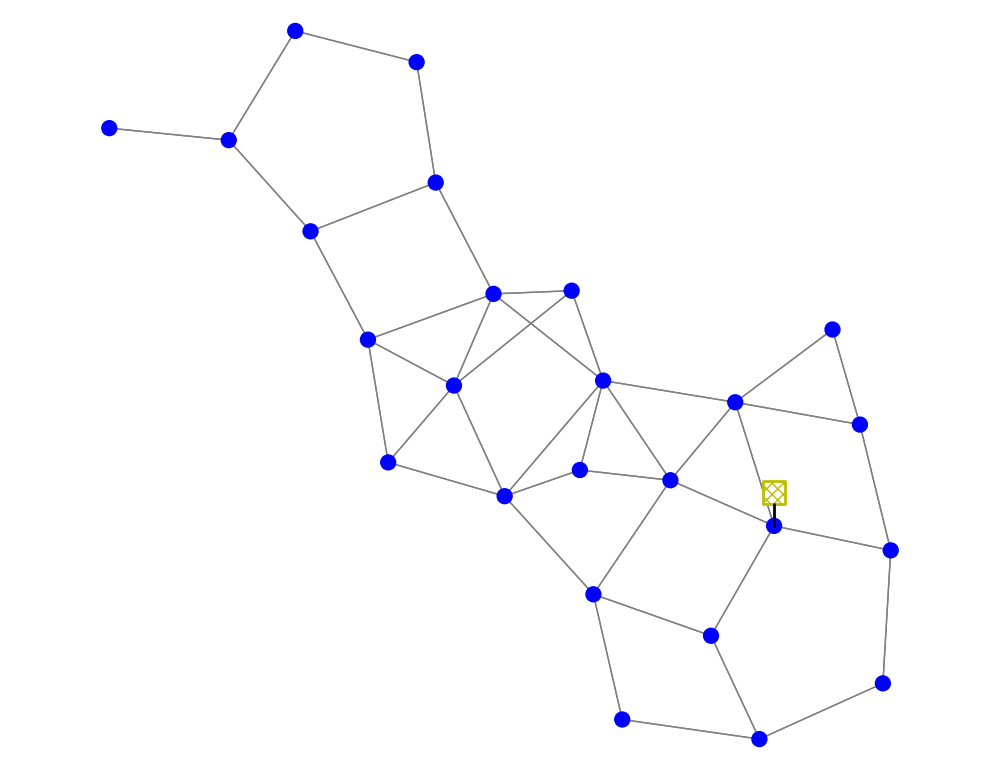

,p_mw,q_mvar
0,1143.228559,-219.595268
1,1292.310750,-228.056953
2,3665.384273,-122.265932
3,3567.190651,-427.785896
4,116.320779,3.481341


In [518]:
#run power flow simulation
pp.runpp(net)
print("Power flow simulation completed.")
# check results
print("Load results:")

#plot power flow map    
simple_plot(net)
display(net.res_load.head())

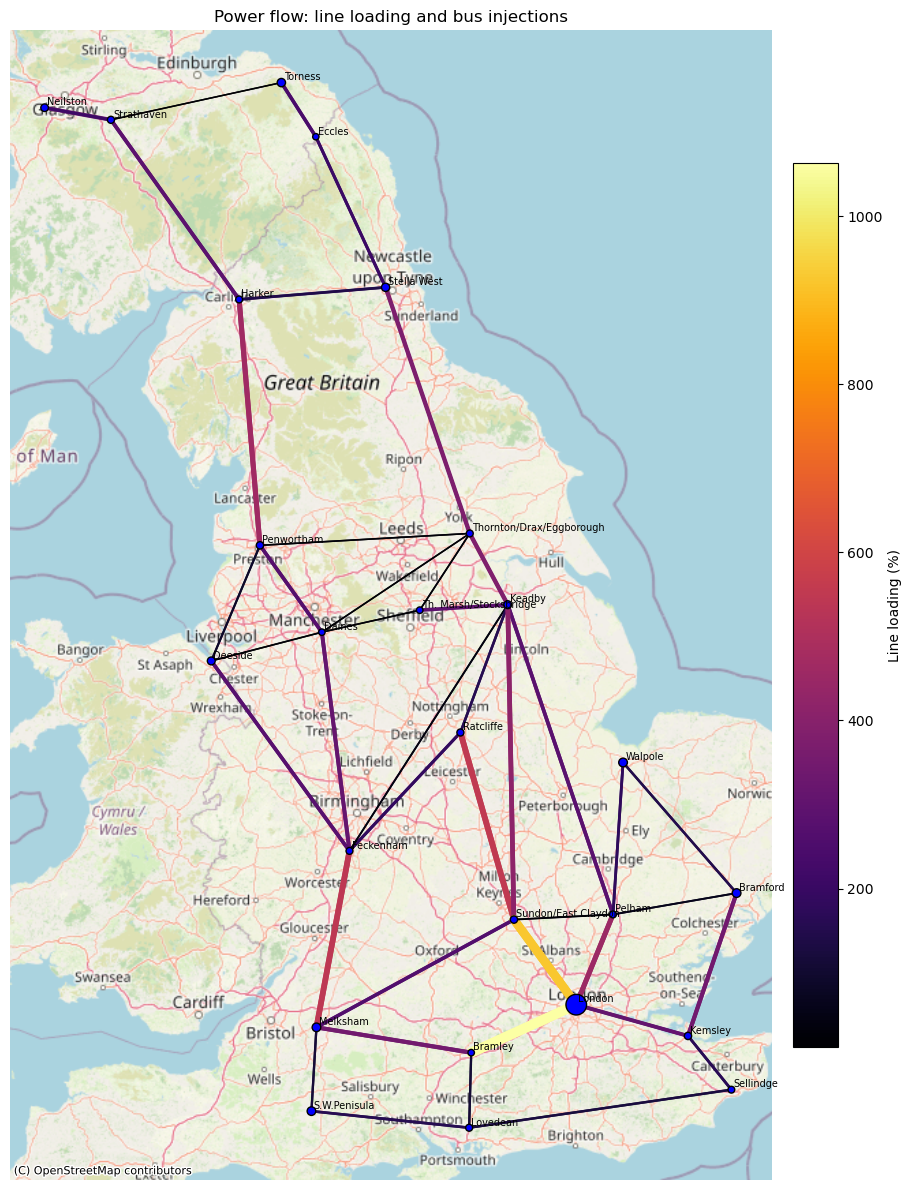

Buses (sample):


,longitude,latitude,name,vn_kv,geometry,p_mw_bus
bus,,,,,,
0,1.159651,52.088738,Bramford,400.0,POINT (1.15965 52.08874),-26346.284441
1,-0.978219,51.291877,Bramley,400.0,POINT (-0.97822 51.29188),-2349.116250
2,-2.181395,53.361456,Daines,400.0,POINT (-2.1814 53.36146),-2179.196727
3,-3.072208,53.223030,Deeside,400.0,POINT (-3.07221 53.22303),-16836.498349
4,-2.229827,55.677255,Eccles,400.0,POINT (-2.22983 55.67725),-1127.157221


Lines (sample):


,index,from_bus,to_bus,loading,geometry
0,0,0,8,341.977333,"LINESTRING (1.15965 52.08874, 0.76818 51.37601)"
1,1,0,8,341.977333,"LINESTRING (1.15965 52.08874, 0.76818 51.37601)"
2,2,0,24,100.727448,"LINESTRING (1.15965 52.08874, 0.24497 52.73048)"
3,3,0,24,149.628563,"LINESTRING (1.15965 52.08874, 0.24497 52.73048)"
4,4,1,10,109.514426,"LINESTRING (-0.97822 51.29188, -0.99502 50.91205)"


In [519]:
# Plot power flow results on geographic map using GeoPandas + Matplotlib + contextily
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import LineString
import pandas as pd

# Verify runpp results exist
if not hasattr(net, 'res_line') or net.res_line is None or net.res_line.shape[0] == 0:
    raise RuntimeError('No line results found in net.res_line — run pp.runpp(net) first')

# Build buses GeoDataFrame from net.bus_geodata and net.bus
buses = net.bus_geodata.copy()
buses = buses.astype({'longitude': float, 'latitude': float})
buses['name'] = net.bus['name'].values
buses['vn_kv'] = net.bus['vn_kv'].values
buses['geometry'] = gpd.points_from_xy(buses['longitude'], buses['latitude'])
gdf_buses = gpd.GeoDataFrame(buses, geometry='geometry', crs='EPSG:4326')

# Attach bus results if available
if hasattr(net, 'res_bus') and net.res_bus is not None and net.res_bus.shape[0] > 0:
    resb = net.res_bus.copy()
    resb['bus'] = resb.index
    # unify active power column
    if 'p_mw' in resb.columns:
        resb['p_mw_bus'] = resb['p_mw']
    elif 'p_kw' in resb.columns:
        resb['p_mw_bus'] = resb['p_kw'] / 1000.0
    else:
        resb['p_mw_bus'] = 0.0
    gdf_buses = gdf_buses.merge(resb[['bus', 'p_mw_bus']], left_index=True, right_on='bus', how='left')
    gdf_buses = gdf_buses.set_index('bus')
else:
    gdf_buses['p_mw_bus'] = 0.0

# Build lines GeoDataFrame with loading info
lines_geoms = []
line_props = []
for idx, row in net.line.iterrows():
    fb = int(row['from_bus'])
    tb = int(row['to_bus'])
    lon1, lat1 = float(net.bus_geodata.loc[fb, 'longitude']), float(net.bus_geodata.loc[fb, 'latitude'])
    lon2, lat2 = float(net.bus_geodata.loc[tb, 'longitude']), float(net.bus_geodata.loc[tb, 'latitude'])
    lines_geoms.append(LineString([(lon1, lat1), (lon2, lat2)]))
    # extract loading percent if available
    loading = 0.0
    if hasattr(net, 'res_line') and 'loading_percent' in net.res_line.columns:
        loading = float(net.res_line.loc[idx, 'loading_percent'])
    elif hasattr(net, 'res_line') and 'loading' in net.res_line.columns:
        loading = float(net.res_line.loc[idx, 'loading'])
    line_props.append({'index': int(idx), 'from_bus': fb, 'to_bus': tb, 'loading': loading})

gdf_lines = gpd.GeoDataFrame(line_props, geometry=lines_geoms, crs='EPSG:4326')

# Project to Web Mercator for basemap plotting
gdf_buses_3857 = gdf_buses.to_crs(epsg=3857)
gdf_lines_3857 = gdf_lines.to_crs(epsg=3857)

# Prepare colormap and normalization for line loading
vmin = gdf_lines_3857['loading'].min() if not gdf_lines_3857['loading'].isna().all() else 0.0
vmax = gdf_lines_3857['loading'].max() if not gdf_lines_3857['loading'].isna().all() else 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.inferno

fig, ax = plt.subplots(figsize=(12, 12))

# Plot lines individually so linewidth can reflect loading
for _, r in gdf_lines_3857.iterrows():
    val = 0.0 if pd.isna(r['loading']) else r['loading']
    color = cmap(norm(val))
    lw = 1.0 + (val / (vmax if vmax>0 else 1.0)) * 6.0  # scale linewidth
    xs, ys = r.geometry.xy
    ax.plot(xs, ys, color=color, linewidth=lw, solid_capstyle='round', zorder=2)

# Add colorbar for loading
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('Line loading (%)')

# Plot buses sized by bus active power (p_mw_bus)
size_series = gdf_buses_3857['p_mw_bus'].abs().fillna(0.0)
if size_series.max() > 0:
    sizes = 20 + (size_series / size_series.max()) * 200
else:
    sizes = 50

gdf_buses_3857.plot(ax=ax, color='blue', markersize=sizes, zorder=3, edgecolor='k')

# Label buses (optional: show only major ones)
for idx, r in gdf_buses_3857.iterrows():
    ax.text(r.geometry.x + 2000, r.geometry.y + 2000, str(r['name']), fontsize=7, zorder=4)

# Add basemap, Open stret map
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title('Power flow: line loading and bus injections')
plt.tight_layout()
plt.show()

# Show sample tables for verification
print('Buses (sample):')
display(gdf_buses.head())
print('Lines (sample):')
display(gdf_lines.head())

In [520]:
# Diagnostic: Identify overloaded lines and contributing buses
import pandas as pd
import numpy as np

if 'net' not in globals() or net.res_line.empty:
    raise RuntimeError("No power flow results. Run pp.runpp(net) first.")

# Find overloaded lines
overloaded = net.res_line[net.res_line['loading_percent'] > 100].copy()

if len(overloaded) == 0:
    print("✓ No overloaded lines found!")
else:
    print(f"\n{'='*70}")
    print(f"OVERLOAD DIAGNOSTIC: {len(overloaded)} overloaded line(s)")
    print(f"{'='*70}\n")
    
    # Sort by loading severity
    overloaded_sorted = overloaded.sort_values('loading_percent', ascending=False)
    
    print("MOST CRITICAL OVERLOADS:")
    print("-" * 70)
    
    for line_idx, (i, row) in enumerate(overloaded_sorted.head(10).iterrows()):
        # Get line details
        line_info = net.line.loc[i]
        from_bus_idx = int(line_info['from_bus'])
        to_bus_idx = int(line_info['to_bus'])
        from_bus_name = str(net.bus.at[from_bus_idx, 'name'])
        to_bus_name = str(net.bus.at[to_bus_idx, 'name'])
        
        # Get power flow
        p_from = row['p_from_mw']
        p_to = row['p_to_mw']
        # Try different rating column names
        sn_mva = None
        for col in ['sn_mva', 's_max_a', 'max_i_ka']:
            if col in line_info.index:
                sn_mva = line_info[col]
                break
        if sn_mva is not None:
            print(f"   Rating: {sn_mva:.2f} MVA")
        else:
            print(f"   Rating: (not specified)")
        
        # Identify demand on receiving side
        buses_with_load = net.load[net.load['bus'] == to_bus_idx]
        buses_with_gen = net.sgen[net.sgen['bus'] == to_bus_idx]
        
        if len(buses_with_load) > 0:
            total_load = buses_with_load['p_mw'].sum()
            print(f"   ↳ {to_bus_name} has {len(buses_with_load)} load(s) totaling {total_load:.2f} MW")
        
        if len(buses_with_gen) > 0:
            total_gen = buses_with_gen['p_mw'].sum()
            print(f"   ↳ {to_bus_name} has {len(buses_with_gen)} generator(s) totaling {total_gen:.2f} MW")
    
    print("\n" + "="*70)
    print("SUMMARY BY BUS")
    print("="*70)
    print("SUMMARY BY BUS")
    # Identify buses involved in overloads
    overload_buses = set(net.line.loc[overloaded.index, 'from_bus']) | set(net.line.loc[overloaded.index, 'to_bus'])
    
    for bus_idx in sorted(overload_buses):
        bus_name = str(net.bus.at[bus_idx, 'name'])
        
        # Lines involving this bus
        lines_from = net.line[net.line['from_bus'] == bus_idx].index
        lines_to = net.line[net.line['to_bus'] == bus_idx].index
        overloaded_from = overloaded.index.intersection(lines_from)
        overloaded_to = overloaded.index.intersection(lines_to)
        
        if len(overloaded_from) > 0 or len(overloaded_to) > 0:
            print(f"\nBus {bus_idx}: {bus_name}")
            
            # Load/generation at this bus
            load_p = net.load[net.load['bus'] == bus_idx]['p_mw'].sum()
            gen_p = net.sgen[net.sgen['bus'] == bus_idx]['p_mw'].sum()
            slack_p = net.res_ext_grid[net.ext_grid['bus'] == bus_idx]['p_mw'].sum() if len(net.ext_grid[net.ext_grid['bus'] == bus_idx]) > 0 else 0.0
            
            print(f"  Demand: {load_p:.2f} MW | Generation: {gen_p:.2f} MW | Slack: {slack_p:.2f} MW")
            
            if len(overloaded_from) > 0:
                print(f"  Overloaded lines outgoing: {list(overloaded_from)}")
            if len(overloaded_to) > 0:
                print(f"  Overloaded lines incoming: {list(overloaded_to)}")
    
    print("\n" + "="*70)
    print("RECOMMENDATIONS")
    print("="*70)
    print("• Increase generator capacity at demand centers")
    print("• Add transmission capacity (upgrade lines or add new lines)")
    print("• Reduce demand through efficiency or demand response")



    print("="*70 + "\n")    
    print("• Improve network topology (reduce path length for power flow)")    
    print("• Add transmission capacity (upgrade lines or add new lines)")
    print("• Reduce demand through efficiency or demand response")
    print("• Improve network topology (reduce path length for power flow)")
    print("="*70 + "\n")



OVERLOAD DIAGNOSTIC: 63 overloaded line(s)

MOST CRITICAL OVERLOADS:
----------------------------------------------------------------------
   Rating: 2.01 MVA
   ↳ London has 1 load(s) totaling 9403.91 MW
   ↳ London has 1 generator(s) totaling 5737.36 MW
   Rating: 2.01 MVA
   ↳ London has 1 load(s) totaling 9403.91 MW
   ↳ London has 1 generator(s) totaling 5737.36 MW
   Rating: 4.73 MVA
   ↳ London has 1 load(s) totaling 9403.91 MW
   ↳ London has 1 generator(s) totaling 5737.36 MW
   Rating: 4.73 MVA
   ↳ London has 1 load(s) totaling 9403.91 MW
   ↳ London has 1 generator(s) totaling 5737.36 MW
   Rating: 3.03 MVA
   ↳ Sundon/East Claydon has 1 load(s) totaling 2871.78 MW
   ↳ Sundon/East Claydon has 1 generator(s) totaling 13244.43 MW
   Rating: 3.03 MVA
   ↳ Sundon/East Claydon has 1 load(s) totaling 2871.78 MW
   ↳ Sundon/East Claydon has 1 generator(s) totaling 13244.43 MW
   Rating: 2.84 MVA
   ↳ Melksham has 1 load(s) totaling 4221.14 MW
   ↳ Melksham has 1 generator(s) to

In [521]:
# totals
total_load_mw = net.load['p_mw'].sum() if 'load' in net else 0.0
total_sgen_mw = net.sgen['p_mw'].sum() if 'sgen' in net else 0.0
total_gen_mw = net.gen['p_mw'].sum() if 'gen' in net else 0.0
total_ext_grid_mw = net.res_ext_grid['p_mw'].sum() if 'res_ext_grid' in net and len(net.res_ext_grid)>0 else None

print("loads (MW):", total_load_mw)
print("sgen (MW):", total_sgen_mw)
print("gens (MW):", total_gen_mw)
print("external grid injections (MW) after runpp (if available):", total_ext_grid_mw)


loads (MW): 57793.34660485122
sgen (MW): 342731.849
gens (MW): 0.0
external grid injections (MW) after runpp (if available): -274672.45840150345
